# 04 · Which funnel stage to invest in? — mediation (pathmc)

**The business decision.** We have a fixed budget to split across the growth funnel —
**onboarding → engagement → activation → conversion** — and want to put it where it moves paid
conversion the most. The complication is that the stages form a **chain**: money spent improving
onboarding doesn't only help onboarding, it *cascades* downstream into engagement, activation, and
ultimately conversion. So we can't just correlate each stage with revenue; we have to trace the causal
*paths* and decide where a push travels furthest.

### The concept: mediation, direct and indirect effects

When a treatment $X$ affects an outcome $Y$ *through* an intermediate variable $M$ (a **mediator**), the
total effect splits in two:

- the **direct effect** — $X$'s influence on $Y$ that does *not* go through $M$ (Pearl's *natural direct
  effect*, NDE);
- the **indirect effect** — the part that flows $X \to M \to Y$ (the *natural indirect effect*, NIE).

Total effect = direct + indirect, and the **proportion mediated** = indirect / total tells you how much
of a stage's value is really realised *downstream*. In a linear model the indirect effect is just the
**product of the coefficients along the path** (the classic "a·b" of mediation analysis) — `pathmc`
gives us exactly this via `effect(path)`, which returns the **posterior product-of-coefficients along the
path** (exact for a linear SCM — not a Monte-Carlo simulation through the graph), so we get every path's effect
*with uncertainty*.

### The catch this notebook is honest about

Mediation leans on a **stronger** assumption than a simple treatment-effect analysis: no unmeasured
confounding of the *mediator–outcome* link (on top of the usual treatment–outcome one). If some
unmeasured trait drives both engagement *and* conversion, the direct/indirect *split* is biased even when
the *total* effect is fine. So Step 6 doesn't just report the split — it **stress-tests how much such
confounding would have to exist to flip the "invest here" decision.**

### Why not just A/B test each stage?

Often you can — and for the **total** effect of one lever, you should. But two things stop
experiments from answering the funnel question on their own. First, mid-funnel stages are hard to
randomize *directly*: you can assign a user a new onboarding flow, but you cannot assign them an
engagement level — engagement is a behaviour, not a knob. Second, even a perfectly randomized
onboarding test identifies only the **total** effect; the direct/indirect *split* — "does onboarding
pay off by itself, or only by feeding engagement?" — still needs the mediator-side assumptions of
Step 3. That is the honest positioning of mediation analysis: it answers a question experiments
alone cannot ("*where in the chain* does the value travel?"), at the price of stronger assumptions —
which is why this notebook spends so much time naming, testing, and stress-testing them.

> **On real data.** Swap in your **product-analytics event data** — per-user onboarding score, engagement,
> activation flag, conversion — which every growth team already logs. The method needs the funnel's causal
> *order* to be known (it usually is) and the no-hidden-mediator-confounder assumption to be defensible
> (Step 6 shows how to argue it).

`pathmc` builds the chain as a structural causal model and computes **path-specific effects** as the posterior
**product-of-coefficients along each path** — exact for a linear SCM (we reserve "simulate through the
intervened graph" for `do()`/`ate()`) — the modern, uncertainty-aware mediation
analysis.

It follows the repo's fixed **7-step contract**: question → simulate → identify → estimate → validate → decide in € → caveats.


In [1]:
import os, json, logging, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import pathmc
import pymc  # noqa: F401 -- imported only to silence its logger below
# Silence sampler chatter (SamplerWarnings log at ERROR, so ERROR is not enough): this notebook refits
# the chain model many times (prior check, fresh-seed replication, fail->fix), and the causal read-outs,
# not the sampler's progress notes, are the story. Convergence is still CHECKED -- printed explicitly
# via est.convergence_report after the main fit.
logging.getLogger("pymc").setLevel(logging.CRITICAL + 1)
from cmp import dgp, plots, estimators as est
from cmp.cache import load_or_run   # fit once, load forever — a live lecture never waits on NUTS
plots.use_style()
FAST = os.environ.get("CMP_FAST", "1") == "1"
FIT = dict(draws=400, tune=400, chains=2) if FAST else dict(draws=1500, tune=1500, chains=4)
SEED = 13
print(f"FAST={FAST}  sampling={FIT}")

def cached_fit(model, key, inputs, **kw):
    """Fit a pathmc model THROUGH the cache. pathmc reads its posterior off `model._idata`, so
    restoring a cached DataTree there makes every downstream .cate()/.effects_summary()/.sensitivity()
    call work with nothing re-sampled."""
    model._idata = load_or_run(key, lambda: model.fit(**kw), inputs=inputs)
    return model._idata


FAST=False  sampling={'draws': 1500, 'tune': 1500, 'chains': 4}


## 2 · Simulate a ground truth

We simulate the funnel as a **causal chain**: `onboarding_score → engagement → activated → converted`,
with `channel_quality` feeding both engagement and activation (a common driver we'll need to account for).
Each arrow is a real structural equation with a planted coefficient, so we know the **true** total effect
of onboarding on conversion *and how it splits across paths* — which is exactly what we'll ask the model
to recover. By construction most of onboarding's effect flows the long way round (`engagement → activated →
converted`), with a smaller slice going `engagement → converted` directly. If the method can rediscover
that split from data alone, we can trust it on a funnel where we *don't* know the answer.

**The data-generating model** — exactly what `dgp.funnel` implements (defaults & seed in
`src/cmp/dgp.py`). Onboarding $O \sim U(0,1)$ (uniform on $[0,1]$ — equally likely anywhere in between) and channel
quality $Q \sim U(0,1)$ are **exogenous** — determined outside the model, with no arrow pointing into them
(both are simply drawn at random); each downstream stage is a linear structural equation:

$$
\begin{aligned}
\text{engagement} &= 2.2\,O + 1.1\,Q + \varepsilon_1, & \varepsilon_1 &\sim \mathcal N(0,\, 0.4^{2})\\
\text{activated} &= 1.6\,\text{engagement} + 0.6\,Q + \varepsilon_2, & \varepsilon_2 &\sim \mathcal N(0,\, 0.4^{2})\\
\text{converted} &= 0.9\,\text{activated} + 0.35\,\text{engagement} + \varepsilon_3, & \varepsilon_3 &\sim \mathcal N(0,\, 0.3^{2}).
\end{aligned}
$$

The planted path effects are the **products of coefficients along each route** — exactly what the
mediation analysis must recover: the long path
$O \to \text{eng} \to \text{act} \to \text{conv} = 2.2 \times 1.6 \times 0.9 = 3.168$, the short
path $O \to \text{eng} \to \text{conv} = 2.2 \times 0.35 = 0.77$, and **no** direct
$O \to \text{conv}$ arrow (true NDE $= 0$), so the true total effect is $3.938$ and the true
proportion mediated is $100\%$. $Q$ feeds two stages (engagement *and* activation) — the common
driver the model must include to keep the paths clean.


In [2]:
df, true_effects = dgp.funnel(n=1000, seed=SEED)
print("TRUE effects of onboarding on conversion:")
for k, v in true_effects.items(): print(f"  {k:36s} {v:.2f}")
df.head()

TRUE effects of onboarding on conversion:
  indirect_via_engagement_activated    3.17
  indirect_via_engagement_only         0.77
  total                                3.94


,onboarding_score,channel_quality,engagement,activated,converted
0,0.864798,0.726815,2.576471,3.869429,4.870321
1,0.855303,0.790067,3.206651,5.673260,6.371102
2,0.811023,0.348493,2.493785,4.691864,5.394113
3,0.261446,0.465793,0.572682,1.261547,1.264003
4,0.077199,0.887974,1.520775,3.259916,3.146544


## 3 · Identify — direct vs indirect effects (NDE / NIE)

For a chain $X\to M\to Y$ the **total effect** decomposes into a **natural direct effect** and
**natural indirect effect** (Pearl):

$$\text{TE}=\text{NDE}+\text{NIE},\quad
\text{NDE}=\mathbb E[Y(1,M(0))-Y(0,M(0))],\quad
\text{NIE}=\mathbb E[Y(1,M(1))-Y(1,M(0))].$$

Here $Y(x,m)$ is the conversion we would see if onboarding were set to $x$ **and** the mediator to
$m$, and $M(x)$ is the mediator value onboarding $x$ would produce — so the NDE holds the mediator at
its *untreated* natural value and moves only the treatment, while the NIE holds the treatment fixed
and swaps which world the mediator comes from. The **proportion mediated** $=\text{NIE}/\text{TE}$
tells you how much of onboarding's value is "really" downstream engagement/activation. Crucially we
**include a direct onboarding→converted edge in the model and test it**, so a near-100%-mediated answer is
*discovered* (the coefficient comes out ≈ 0), not forced by leaving the edge out.

### What buys the decomposition — sequential ignorability, one condition at a time

The NDE/NIE are **cross-world** quantities — $Y(1,M(0))$ mixes a treated outcome with an untreated
mediator, a combination *no experiment ever shows you*. Identifying them takes four conditions
(from the mediation-analysis literature — Imai et al.; VanderWeele), stated with $X=$ onboarding, $M=$ the mediator(s), $Y=$ conversion, and
$C=$ the observed common drivers (here `channel_quality`):

*Reading the notation.* $A \perp B \mid C$ means "once we know $C$, $A$ carries no information about $B$" (they are statistically independent given $C$); $\mathbb E[\cdot]$ is an average; $\int \cdots\, dP(\cdot)$ is that same average written as an integral — a probability-weighted sum over the values of whatever follows $dP$; and a **prime** ($x'$) marks a *possibly different* treatment value than $x$ — that mismatch between the world the outcome lives in and the world the mediator comes from is exactly what makes these quantities "cross-world."

*Ignorability* itself means: given the controls $C$, who got the treatment is as-good-as-random, so we can "ignore" how assignment happened. Ordinary treatment-effect analysis needs this once (SI-1); mediation needs it **again for the mediator** (SI-2, SI-4) — that extra demand is why it is called *sequential* ignorability and why it is strictly stronger.

$$\text{(SI-1)}\qquad \{\,Y(x,m),\; M(x')\,\}\ \perp\ X \ \big|\ C$$

*No unmeasured treatment-side confounding*: given $C$, who got good onboarding is as-good-as-random
with respect to both outcome and mediator. **Violation:** highly motivated users both breeze through
onboarding *and* would convert anyway — motivation is unlogged, and onboarding inherits its credit.

$$\text{(SI-2)}\qquad Y(x,m)\ \perp\ M \ \big|\ X{=}x,\ C$$

*No unmeasured mediator–outcome confounding* — **the killer**, because $M$ is a behaviour, never
randomized even inside an RCT. **Violation:** a user's intrinsic interest in the product drives both
their engagement *and* their conversion; the fitted engagement→conversion edge then overstates the
mechanism and the direct/indirect split is wrong even when the total is fine. This is the assumption
Step 6 stress-tests quantitatively.

$$\text{(SI-3)}\qquad 0 \;<\; p\big(M{=}m \mid X,\,C\big)\ \ \text{for all } m \ \ \text{(positivity)}$$

Every mediator level must be *reachable* at every treatment level — if no low-onboarding user ever
shows high engagement, the counterfactual "high engagement without onboarding" is pure extrapolation.

$$\text{(SI-4)}\qquad Y(x,m)\ \perp\ M(x') \ \big|\ C \qquad \text{(cross-world independence)}$$

No mediator–outcome confounder that is *itself caused by* $X$ — e.g. onboarding must not create a
habit that separately drives both engagement and conversion. This one is **untestable even in
principle** (the two sides live in different worlds), which is the honest price of asking a
cross-world question.

### The mediation formula — what the assumptions buy

Under SI-1–SI-4, the cross-world mean is identified by the **mediation formula** (Pearl/Imai):

$$\mathbb E\big[Y\big(x,\,M(x')\big)\big] \;=\; \int_m \mathbb E\big[\,Y \mid X{=}x,\ M{=}m,\ C\,\big]\; dP\big(m \mid X{=}x',\ C\big)\; dP(C).$$

Read it as a recipe — the outer $\int \cdots\, dP(m \mid X{=}x', C)$ is exactly the "average over the mediator values that treatment $x'$ would produce" from the notation key above: predict the outcome under treatment $x$, but average over the mediator
distribution that treatment $x'$ *would have produced*. This is the estimator-agnostic result —
everything `pathmc` computes below is this formula specialized to a linear Gaussian (Gaussian = normal) SCM.

### From formula to "product of coefficients" — two lines

For the simple chain with one mediator, let $M = a\,X+\varepsilon_M$ and
$Y = c\,X + b\,M + \varepsilon_Y$ (noise mean-zero, no $X{\times}M$ interaction). Then
$\mathbb E[Y \mid X{=}x, M{=}m] = c\,x + b\,m$ and $\mathbb E[M \mid X{=}x'] = a\,x'$, so the
mediation formula collapses to

$$\mathbb E\big[Y\big(x, M(x')\big)\big] \;=\; c\,x \;+\; b\,a\,x' \qquad\Longrightarrow\qquad
\text{NDE}=c\,\Delta x,\quad \text{NIE}=a\,b\,\Delta x,\quad \text{TE}=(c+ab)\,\Delta x.$$

That is the classic $a\!\cdot\!b$ of mediation analysis, now *derived* rather than asserted — and it
is why `effect(path)` returns the **posterior product of the coefficients along the path**, exact for
a linear SCM (not a Monte-Carlo simulation through the graph), so every path effect comes *with
uncertainty*. One subtlety for our **continuous** treatment: the effects here are per-unit contrasts
($x \to x+1$), and because the SCM is linear with no interaction they are the same at every $x$ —
with nonlinearity or interaction, NDE/NIE would depend on the baseline and the clean additivity
above would need the four-way (VanderWeele) decomposition (Step 7).

### Two mediators in sequence — path-specific effects need one more condition

Our funnel has **two ordered mediators** (engagement → activated), so "indirect via activated" is a
*path-specific effect*, and its identification needs, on top of SI-1–SI-4, **no unmeasured
confounding between the mediators themselves**. That is exactly why the DGP's `channel_quality` —
which feeds *both* engagement and activation — must be observed and adjusted: leave it out and the
engagement→activated edge silently absorbs its effect, poisoning every path product built on that
edge. Step 5 doesn't leave this as a warning: we *refit without it and watch the split break*.

**Which assumption breaks first in practice?** SI-2 (and its mediator–mediator cousin) — you can
randomize onboarding but never engagement. So Step 6 doesn't just report the split; it measures how
much hidden mediator–outcome confounding it would take to change the *decision*.

## Step 0 · The classical read (no likelihood, no priors, no sampler)

Before any Bayesian machinery, ask what a competent analyst does here **without** it. The answer is not a
different analysis: it is the *same estimands* (the NDE and NIE of §3), bought by the *same four
conditions* (SI-1–SI-4), estimated with the oldest tool in the mediation literature — **two OLS
regressions and a multiplication**. That is the **product-of-coefficients** method (Baron–Kenny 1986;
Preacher–Hayes 2008 for the interval), and it is what a good analyst would put in the deck tomorrow
morning. The causal work lives in the identification argument, not in the machinery — and it is worth
seeing that once, cleanly, before likelihoods and priors arrive and start doing work of their own.

**The estimator, naked.** With treatment $X=$ `onboarding_score`, mediator $M=$ `engagement`, outcome
$Y=$ `converted` and the observed common driver $C=$ `channel_quality`, fit two ordinary least-squares
regressions —

$$
\begin{aligned}
M_i &= \alpha_0 + a\,X_i + \gamma\,C_i + \varepsilon^M_i, &&\text{(treatment} \to \text{mediator)}\\
Y_i &= \beta_0 + c\,X_i + b\,M_i + \delta\,C_i + \varepsilon^Y_i, &&\text{(both} \to \text{outcome)}
\end{aligned}
$$

— and read the decomposition straight off the coefficients:

$$\widehat{\text{NIE}} = \hat a\,\hat b,\qquad \widehat{\text{NDE}} = \hat c,\qquad
\widehat{\text{TE}} = \hat a\,\hat b + \hat c .$$

This is not a rival theory. It is *literally* the mediation formula of §3 specialised to a linear SCM —
the two lines already derived above, with every symbol now a regression coefficient. Nothing else is
needed: no likelihood, no prior, no sampler.

**Which mediator — and the regression you must *not* run.** Our funnel has **two ordered** mediators
(engagement → activated), so the single-mediator read takes $M=$ `engagement` and deliberately leaves
`activated` **out** of the outcome regression. `activated` sits *on the path*
engagement → activated → converted; put it on the right-hand side and you **block** that path. Then
$\hat b$ stops being engagement's total effect on conversion (reduced form: $0.9\times1.6+0.35=1.79$ in
this DGP) and collapses to its direct-only slice ($0.35$) — a five-fold understatement of the mediated
effect. The cell below prints both numbers so the trap is visible, not merely asserted. It is the same
"don't control away the mechanism" error that §4's naive regression will spring on the *treatment*; here
it is sprung on the *mediator*, and it is the single most common way an applied mediation analysis is
quietly wrong.

To recover the **path-specific** pieces that §5 will report (long route vs short route), we then chain
the same product over three regressions — one per stage, exactly the equations the Bayesian spec will
use in §4 — and multiply along each route. Same arithmetic, one level up.

**Why a bootstrap and not a $t$-statistic.** The indirect effect is a **product** of two estimates. Even
when $\hat a$ and $\hat b$ are each normal, $\hat a\hat b$ is not: its sampling distribution is skewed
(it is a product of correlated normals), and the textbook delta-method standard error

$$\text{SE}_{\Delta}(\hat a \hat b)\;\approx\;\sqrt{\hat b^{2}\,\text{SE}(\hat a)^{2} + \hat a^{2}\,\text{SE}(\hat b)^{2}}$$

is only a **first-order** approximation to it. So the applied literature resamples: refit *both*
regressions on bootstrap replicates of the rows and take percentiles of $\hat a\hat b$ — a
**nonparametric bootstrap** interval, which is what `cl.mediation_product` returns. We print the
delta-method SE next to the bootstrap SE, so you can see for yourself how much the approximation was off
*here* rather than take the textbook's word for it.

In [3]:
from cmp import classical as cl
import statsmodels.formula.api as smf

N_BOOT = 400 if FAST else 2000          # the bootstrap is the only expensive thing in Step 0
ALPHA = 0.10                            # 90% intervals, to match every posterior interval in this notebook

# --- (1) The product-of-coefficients decomposition: two OLS regressions, one multiplication ---------
#     M: engagement ~ a*onboarding + channel_quality
#     Y: converted  ~ c*onboarding + b*engagement + channel_quality
#     channel_quality is the observed common driver: it confounds engagement->converted (through
#     activated), so it MUST be in both equations.
#     NIE = a*b    NDE = c    TE = a*b + c
med = cl.mediation_product(df, outcome="converted", treatment="onboarding_score",
                           mediator="engagement", controls=["channel_quality"],
                           n_boot=N_BOOT, alpha=ALPHA, seed=SEED)

# The planted truth: onboarding has NO direct arrow into converted, so the whole total effect is indirect.
TRUE = {"nie": true_effects["total"], "nde": 0.0, "total": true_effects["total"]}
print(f"BARON-KENNY / product-of-coefficients   (n = {med['nie'].n:,}; intervals from a")
print(f"nonparametric bootstrap, {N_BOOT} resamples -- the SE column is the bootstrap SD)\n")
print(f"{'quantity':22}{'est':>6}{'SE':>7}{'90% CI':>16}{'truth':>7}  covers?")
for k in ("nie", "nde", "total"):
    r, t = med[k], TRUE[k]
    print(f"{r.name:22}{r.estimate:>6.2f}{r.se:>7.2f}{f'[{r.ci[0]:.2f}, {r.ci[1]:.2f}]':>16}{t:>7.2f}"
          f"  {'yes' if r.ci[0] <= t <= r.ci[1] else 'NO'}")
print(f"\nproportion mediated (NIE/TE), plug-in: {med['nie'].estimate / med['total'].estimate:.0%}"
      f"  (planted {TRUE['nie'] / TRUE['total']:.0%}: the funnel is the whole story)")

# --- (2) The regression you must NOT run: put the SECOND mediator on the right-hand side ------------
b_ok  = smf.ols("converted ~ onboarding_score + engagement + channel_quality", data=df).fit()
b_bad = smf.ols("converted ~ onboarding_score + engagement + activated + channel_quality", data=df).fit()
B_REDUCED, B_DIRECT = 0.9 * 1.6 + 0.35, 0.35     # planted: engagement's TOTAL vs DIRECT effect on conversion
print("\nTHE MEDIATOR-BLOCKING TRAP -- b, the engagement->converted edge, two ways:")
print(f"  activated LEFT OUT  (right) : b = {b_ok.params['engagement']:.2f}"
      f"   planted reduced form 0.9*1.6 + 0.35 = {B_REDUCED:.2f}")
print(f"  activated CONTROLLED (wrong): b = {b_bad.params['engagement']:.2f}"
      f"   planted direct-only slice = {B_DIRECT:.2f}")
print(f"  -> conditioning on a variable ON the path blocks it. The NIE would read")
print(f"     {med['nie'].estimate * b_bad.params['engagement'] / b_ok.params['engagement']:.2f} "
      f"instead of {med['nie'].estimate:.2f}: an ~"
      f"{b_ok.params['engagement'] / b_bad.params['engagement']:.0f}x understatement of the funnel.")

# --- (3) Bootstrap vs delta method: how skewed is the product, really? -------------------------------
ma = smf.ols("engagement ~ onboarding_score + channel_quality", data=df).fit()
a_hat, se_a = ma.params["onboarding_score"], ma.bse["onboarding_score"]
b_hat, se_b = b_ok.params["engagement"], b_ok.bse["engagement"]
se_delta = float(np.sqrt(b_hat**2 * se_a**2 + a_hat**2 * se_b**2))
print(f"\nSE of the indirect effect a*b:  delta method {se_delta:.3f}  vs  bootstrap "
      f"{med['nie'].se:.3f}  (ratio {med['nie'].se / se_delta:.2f})")

BARON-KENNY / product-of-coefficients   (n = 1,000; intervals from a
nonparametric bootstrap, 2000 resamples -- the SE column is the bootstrap SD)

quantity                 est     SE          90% CI  truth  covers?
NIE (indirect, a*b)     3.84   0.11    [3.67, 4.03]   3.94  yes
NDE (direct, c)         0.06   0.09   [-0.10, 0.21]   0.00  yes
Total effect            3.90   0.09    [3.75, 4.06]   3.94  yes

proportion mediated (NIE/TE), plug-in: 99%  (planted 100%: the funnel is the whole story)

THE MEDIATOR-BLOCKING TRAP -- b, the engagement->converted edge, two ways:
  activated LEFT OUT  (right) : b = 1.79   planted reduced form 0.9*1.6 + 0.35 = 1.79
  activated CONTROLLED (wrong): b = 0.33   planted direct-only slice = 0.35
  -> conditioning on a variable ON the path blocks it. The NIE would read
     0.71 instead of 3.84: an ~5x understatement of the funnel.

SE of the indirect effect a*b:  delta method 0.114  vs  bootstrap 0.108  (ratio 0.95)


In [4]:
# --- (4) The SAME product, chained over the whole funnel: the path-specific effects ------------------
# Three regressions -- one per stage, EXACTLY the equations the Bayesian spec will use in Step 4 -- and
# multiply the coefficients along each route. Here `activated` DOES belong in the converted equation:
# we now WANT to split the long route from the short one, not to measure engagement's total.
def path_products(d, use_Q=True):
    # The four quantities Step 5 will report, as plug-in products of OLS coefficients.
    q = " + channel_quality" if use_Q else ""
    e_on  = smf.ols(f"engagement ~ onboarding_score{q}", data=d).fit().params["onboarding_score"]
    a_eng = smf.ols(f"activated ~ engagement{q}", data=d).fit().params["engagement"]
    p     = smf.ols("converted ~ activated + engagement + onboarding_score", data=d).fit().params
    via_act, via_eng, direct = e_on * a_eng * p["activated"], e_on * p["engagement"], p["onboarding_score"]
    return np.array([via_act + via_eng + direct, direct, via_act, via_eng])

KEYS = ["total", "direct", "via_act", "via_eng"]
NAMES = {"total": "TOTAL onboarding->conv", "direct": "DIRECT (NDE)",
         "via_act": "indirect eng->act->conv", "via_eng": "indirect eng->conv"}
cl_est = path_products(df)
rng_b = np.random.default_rng(SEED)                       # one bootstrap, four statistics: resample ROWS,
boot = np.array([path_products(df.iloc[rng_b.integers(0, len(df), len(df))])   # refit all three stages,
                 for _ in range(N_BOOT)])                                      # recompute every product
lo, hi = np.percentile(boot, [100 * ALPHA / 2, 100 * (1 - ALPHA / 2)], axis=0)
cl_paths = {k: cl.Classical(NAMES[k], float(cl_est[i]), float(boot[:, i].std(ddof=1)), (float(lo[i]), float(hi[i])),
                            ALPHA, f"nonparametric bootstrap ({N_BOOT} resamples)", len(df))
            for i, k in enumerate(KEYS)}
cl_prop = cl.Classical("proportion mediated (NIE/TE)",
                       float(1 - cl_est[1] / cl_est[0]), float((1 - boot[:, 1] / boot[:, 0]).std(ddof=1)),
                       tuple(np.percentile(1 - boot[:, 1] / boot[:, 0], [5, 95]).astype(float)),
                       ALPHA, f"nonparametric bootstrap ({N_BOOT} resamples)", len(df))

TRUTHS = {"total": true_effects["total"], "direct": 0.0,
          "via_act": true_effects["indirect_via_engagement_activated"],
          "via_eng": true_effects["indirect_via_engagement_only"]}
print("THE WHOLE DECOMPOSITION, CLASSICALLY")
print("(plug-in products of OLS coefficients; bootstrap 90% CIs)\n")
print(f"{'quantity':30}{'est':>7}{'90% CI':>17}{'truth':>8}  covers?")
for k in KEYS:
    r, t = cl_paths[k], TRUTHS[k]
    print(f"{r.name:30}{r.estimate:>7.2f}{f'[{r.ci[0]:.2f}, {r.ci[1]:.2f}]':>17}{t:>8.2f}  "
          f"{'yes' if r.ci[0] <= t <= r.ci[1] else 'NO'}")
n_cov = sum(cl_paths[k].ci[0] <= TRUTHS[k] <= cl_paths[k].ci[1] for k in KEYS)
print(f"{cl_prop.name:30}{cl_prop.estimate:>7.0%}{f'[{cl_prop.ci[0]:.0%}, {cl_prop.ci[1]:.0%}]':>17}{1.0:>8.0%}  "
      f"{'yes' if cl_prop.ci[0] <= 1.0 <= cl_prop.ci[1] else 'NO'}")
print(f"\n{n_cov} of {len(KEYS)} bootstrap intervals cover their planted truth, and the DIRECT")
print(f"effect's interval "
      f"{'includes' if cl_paths['direct'].ci[0] <= 0 <= cl_paths['direct'].ci[1] else 'EXCLUDES'} zero"
      f" -- so two OLS regressions and a multiplication already")
print("say: onboarding works almost entirely THROUGH the funnel.")
print("\n" + cl_paths["total"].cannot_say())

THE WHOLE DECOMPOSITION, CLASSICALLY
(plug-in products of OLS coefficients; bootstrap 90% CIs)

quantity                          est           90% CI   truth  covers?
TOTAL onboarding->conv           3.92     [3.77, 4.07]    3.94  yes
DIRECT (NDE)                     0.06    [-0.03, 0.15]    0.00  yes
indirect eng->act->conv          3.13     [2.97, 3.31]    3.17  yes
indirect eng->conv               0.72     [0.57, 0.88]    0.77  yes
proportion mediated (NIE/TE)      98%      [96%, 101%]    100%  yes

4 of 4 bootstrap intervals cover their planted truth, and the DIRECT
effect's interval includes zero -- so two OLS regressions and a multiplication already
say: onboarding works almost entirely THROUGH the funnel.

What this 90% confidence interval does NOT say: that there is a 90% probability the true effect lies inside it. It is a property of the *procedure* — 90% of intervals built this way would cover the truth across repeated samples. This interval either contains the truth or it d

**Read-out — the classical answer, in business terms.** Two regressions and a multiplication reproduce
the entire funnel story printed above: onboarding's total effect on conversion is ≈ 3.9 conversion units
per unit of onboarding score, the **direct** effect is indistinguishable from zero (its bootstrap
interval straddles it), and therefore ~100% of onboarding's value is **mediated** — realised two stages
downstream, in engagement and activation. Every interval covers its planted truth. Chained over the
three stage equations, the same arithmetic even splits the indirect effect into its long route
(engagement → activated → converted) and its short one (engagement → converted), and both land on their
planted values. **This is a competent, correct, complete answer to §3's question, and it took
milliseconds.** Hold on to it: §5x lays it next to the posterior, and the comparison is not flattering
to the machinery.

Two things the print-out settles, and they cut in opposite directions:

- **The bootstrap was worth running, and it barely mattered.** Both are true, and the printed ratio says
  so: with $n=1{,}000$ and both $\hat a$ and $\hat b$ far from zero, the product $\hat a\hat b$ is close
  enough to normal that the delta-method SE and the bootstrap SE agree to within a few percent. The
  bootstrap's value here is not a *correction* — it is the fact that you **could not have known that in
  advance**. The product's skew bites precisely when one of the two links is weak (a small $\hat a$ pulls
  $\hat a\hat b$'s distribution off-normal and the delta interval starts covering at less than its
  nominal rate), which is exactly the regime — a marginal first link — where the analyst most wants a
  trustworthy interval. Bootstrap by default; be pleased, not disappointed, when it agrees.
- **The mediator-blocking trap is not hypothetical.** Sliding `activated` into the outcome regression —
  a variable any analyst would call "an obvious control for conversion" — cuts $\hat b$ by the printed
  factor and would have reported an indirect effect five times too small, i.e. a funnel investment
  priced at a fifth of its worth. The rule is the one §3 already stated in reverse: **never condition on
  a variable that lies on the path you are trying to measure.**

**And now the part that matters most — the causal content is not in the algebra.** Look at what we just
did: nothing but least squares. Yet the number we called $\hat a\hat b$ is the **natural indirect
effect** only if SI-1–SI-4 hold — in particular **SI-2**, no unmeasured mediator–outcome confounding.
If a hidden trait (intrinsic product interest, say) drives *both* engagement and conversion, then $\hat
b$ is not the causal engagement → conversion edge, $\hat a \hat b$ is not the NIE, and the split is
wrong even when the total is fine. **No regression tests that. No bootstrap tests that.** Resampling the
rows tells you how much $\hat a\hat b$ would wobble across samples *from the same confounded population*
— it re-estimates the same biased quantity a thousand times and reports how stable the bias is. A tight
bootstrap interval around a confounded number is a confident wrong answer, and this is the sense in
which mediation is *strictly harder* than the treatment-effect problems of notebooks 08 or 10: there,
randomisation could in principle be bought; here, the mediator is a behaviour that no experiment ever
assigns.

Be clear that **Bayes will not rescue you from this either.** The section that follows fits the same
edges under the same assumption; if SI-2 fails, the posterior is confidently wrong in exactly the same
direction, by exactly the same amount. §5's fail → fix refit shows this happening — and §5x will show
that the classical arm breaks *identically*, to two decimal places. What the Bayesian layer changes is
not the identification but the **uncertainty accounting** (a coherent joint posterior over $a$, $b$, $c$,
so the product carries its uncertainty exactly and the proportion mediated comes with an interval as a
*derived* quantity) and the **sensitivity analysis** (§6's coherent sweep, where the assumption's
consequences are priced in euros with bands). Those are real, and §5x measures exactly how big they are.

**The guardrail — what that confidence interval does *not* say** (printed above, and printed in the same
words in every notebook of this cookbook): it is **not** a 90% probability that the true indirect effect
lies inside it. A confidence interval is a property of the *procedure* — 90% of intervals built this way
cover the truth across repeated samples — and this one either covers it or does not. Here is where that
bites: §6 must answer *"what is the probability engagement's euro leverage beats activation's?"* and
*"what is the probability this lever's ROI clears 1?"*. Those sentences ask for probabilities **about
the effects themselves**. The classical apparatus has none to give — not because its arithmetic is
worse, but because such a quantity does not exist in its vocabulary. It exists in a posterior.

## 4 · Estimate — fit the chain and query every path

We hand `pathmc` the **whole chain at once** — one equation per stage — rather than three disconnected
regressions. That matters: because the model knows the full graph, it can propagate an intervention on
onboarding *through* engagement and activation to conversion, giving genuine path-specific effects instead
of naive stage-by-stage correlations. The `effects_summary()` below lists every structural coefficient
(the $a$'s and $b$'s from Step 3); Step 5 then combines them into total, direct, and indirect effects with
uncertainty.

Throughout, uncertainty is reported as a **credible interval** — the Bayesian analogue of a confidence interval, the range that contains the parameter with the stated posterior probability; note the `effects_summary()` table below shows a **94% HDI (highest-density interval)** — the narrowest credible interval containing 94% of the posterior — (`hdi_3%`/`hdi_97%`) while Step 5's print reports a **90%** interval.

A **prior** is the belief we hold about a coefficient *before* seeing data; after fitting, the **posterior** is that belief updated by the data — every effect below is read off this posterior, so it comes with a spread, not just a point.

**Reading the sampler's health check** (printed right after the fit). Three numbers say whether the MCMC sampler — the algorithm that draws samples from the posterior — actually converged: **R-hat** compares the variance within each chain to the variance across chains (1.00 is perfect, **≤ 1.01 is the usual pass bar**); **ESS** (effective sample size) is how many *independent* draws our autocorrelated chains are worth (a few hundred is ample for a posterior mean or interval); **divergences** are steps where the sampler broke down and distrusts that region — **you want 0**. Under this notebook's FAST teaching profile the chains are deliberately short, so R-hat can drift to ~1.02 and PyMC may print a "problems during sampling" notice — a benign small-draw artifact that clears in a FULL run — as here: this committed FULL fit reports R-hat at/near 1.00, ESS in the thousands, and 0 divergences; the fresh-seed replication in Step 5 is the real backstop.

**The fitted model, in symbols** — exactly the three structural equations of step 2, refit with a
coefficient posterior on every arrow, *plus* one extra edge (`c_on`, a direct
$O \to \text{converted}$ arrow) we include deliberately even though we suspect it is zero, so
"how much is mediated?" is *discovered* (its posterior should sit at ≈ 0) rather than assumed by
omission. Each coefficient gets a weakly-informative normal prior — printed, written out in full, and
stress-tested immediately after the fit — and `effect(path)` returns the
**product of the posterior coefficient draws along the path** — e.g. the long path's effect is the
posterior of $e_{on} \cdot a_{eng} \cdot c_{act}$, uncertainty included.


In [5]:
# We INCLUDE a direct onboarding_score -> converted edge (c_on) even though we suspect there
# isn't one, so the 'how much is mediated?' answer is DISCOVERED (c_on's posterior ~ 0) rather
# than assumed by omitting the edge.
spec = '''
engagement ~ e_on*onboarding_score + e_ch*channel_quality
activated  ~ a_eng*engagement + a_ch*channel_quality
converted  ~ c_act*activated + c_eng*engagement + c_on*onboarding_score
'''
m = pathmc.model(spec, data=df)
idata = cached_fit(m, "04_mediation_main", dict(seed=SEED, fast=FAST, spec=spec, **FIT),
                   random_seed=SEED, progressbar=False, **FIT)
conv_main = est.convergence_report(idata)["summary"]   # temp var: {d["k"]} inside an f-string needs Python >= 3.12
print(f"mediation model convergence: {conv_main}")
m.effects_summary().round(3)


[cache] ADOPTING the pre-fingerprint fit for '04_mediation_main'. You are asserting that neither its model code nor its data has changed. Renaming, not copying, so this happens exactly once.
[cache] loaded '04_mediation_main' (13s fit, cached 11.2h ago) — nothing re-sampled.


mediation model convergence: max r-hat 1.000 - min ESS 3737 - divergences 0


,mean,sd,hdi_3%,hdi_97%
name,,,,
e_on,2.153,0.045,2.074,2.241
e_ch,1.132,0.044,1.053,1.222
a_eng,1.617,0.018,1.585,1.652
a_ch,0.592,0.051,0.491,0.681
c_act,0.901,0.022,0.858,0.941
c_eng,0.336,0.045,0.251,0.420
c_on,0.060,0.055,-0.044,0.162


### The model we actually fit — likelihood, priors, and whether they matter

Before reading a single effect, write the model down. `pathmc` compiled the spec into three Gaussian
likelihoods — one per stage — each with an intercept the DGP doesn't have (harmless; its posterior
sits at ≈ 0) and a weakly-informative prior on every coefficient:

$$
\begin{aligned}
\text{engagement}_i &\sim \mathcal N\big(\beta_{0}^{(1)} + e_{on}\,O_i + e_{ch}\,Q_i,\ \sigma_1^2\big),\\
\text{activated}_i &\sim \mathcal N\big(\beta_{0}^{(2)} + a_{eng}\,\text{engagement}_i + a_{ch}\,Q_i,\ \sigma_2^2\big),\\
\text{converted}_i &\sim \mathcal N\big(\beta_{0}^{(3)} + c_{act}\,\text{activated}_i + c_{eng}\,\text{engagement}_i + c_{on}\,O_i,\ \sigma_3^2\big),
\\[4pt]
\beta_\bullet &\sim \mathcal N(0,\ 10^2), \qquad \sigma_\bullet \sim \text{HalfNormal}(1).
\end{aligned}
$$

**Why these priors are safe here.** Every variable lives on a roughly unit scale ($O,Q\in[0,1]$, the
stages are small multiples of them), the planted coefficients are all below 2.5 and the noise scales
0.3–0.4 — so $\mathcal N(0,10^2)$ is diffuse relative to any plausible effect and
$\text{HalfNormal}(1)$ generous for the noise, and with $n=1000$ the likelihood should dominate.
"Should" is checkable: the cell below **doubles every prior scale and refits**. If the posterior
means move by more than Monte-Carlo error, the priors were doing the talking; if nothing moves, the
data set these numbers. We also finally read the Step-4 coefficient table **against the planted
truth**, arrow by arrow — the path products of Step 5 are only as good as the arrows they multiply.

In [6]:
print(m.priors())

# (a) Read the fitted coefficients against the planted truth, arrow by arrow.
truth_coef = {"e_on": 2.2, "e_ch": 1.1, "a_eng": 1.6, "a_ch": 0.6, "c_act": 0.9, "c_eng": 0.35, "c_on": 0.0}
summ = m.effects_summary()
chk = pd.DataFrame({"posterior mean": summ["mean"], "posterior sd": summ["sd"],
                    "planted truth": [truth_coef[k] for k in summ.index]})
chk["|z|"] = (chk["posterior mean"] - chk["planted truth"]).abs() / chk["posterior sd"]
print(chk.round(3).to_string())
worst = float(chk["|z|"].max())
print(f"{'Every' if worst <= 2 else 'NOT every'} coefficient's posterior mean sits within 2 posterior sd of its "
      f"planted value (worst |z| = {worst:.1f}) -- the individual arrows are {'recovered' if worst <= 2 else 'off'}, "
      f"so the path products in Step 5 rest on {'sound' if worst <= 2 else 'shaky'} pieces.")

# (b) Prior sensitivity: double every coefficient's prior scale and refit.
wide = {f"beta_{v}": pathmc.Prior("Normal", mu=0, sigma=20) for v in ("engagement", "activated", "converted")}
m_wide = pathmc.model(spec, data=df, priors=wide)
idata_wide = cached_fit(m_wide, "04_mediation_wide_priors",
                        dict(seed=SEED, fast=FAST, spec=spec, prior="Normal(0,20)", **FIT),
                        random_seed=SEED, progressbar=False, cores=1, **FIT)
conv_wide = est.convergence_report(idata_wide)["summary"]
print(f"\nwide-prior refit convergence: {conv_wide}")   # its numbers are quoted below, so it gets a read-out too
shift = (m_wide.effects_summary()["mean"] - summ["mean"]).abs()
rel = float((shift / summ["sd"]).max())
print(f"\nDoubling every prior scale (Normal(0,10) -> Normal(0,20)) moves the largest posterior mean by "
      f"{shift.max():.3f} ({rel:.2f} posterior sd) -- "
      + ("the data, not the priors, set these numbers." if rel < 0.5
         else "a non-trivial prior influence; treat the priors as informative and justify them."))

Priors:
  beta_engagement: Normal(mu=0, sigma=10)
  sigma_engagement: HalfNormal(sigma=1)
  beta_activated: Normal(mu=0, sigma=10)
  sigma_activated: HalfNormal(sigma=1)
  beta_converted: Normal(mu=0, sigma=10)
  sigma_converted: HalfNormal(sigma=1)
       posterior mean  posterior sd  planted truth    |z|
name                                                     
e_on            2.153         0.045           2.20  1.059
e_ch            1.132         0.044           1.10  0.713
a_eng           1.617         0.018           1.60  0.948
a_ch            0.592         0.051           0.60  0.163
c_act           0.901         0.022           0.90  0.034
c_eng           0.336         0.045           0.35  0.300
c_on            0.060         0.055           0.00  1.093
Every coefficient's posterior mean sits within 2 posterior sd of its planted value (worst |z| = 1.1) -- the individual arrows are recovered, so the path products in Step 5 rest on sound pieces.
[cache] ADOPTING the pre-fingerpri

### Model criticism — a posterior predictive check per stage equation

Convergence says the sampler explored the posterior; it says nothing about whether the **model can
generate the data**. A mediation model is *three* likelihoods chained together, and the failure mode
is multiplicative: a misfit in any one stage equation contaminates **every path product built through
it** — an over-dispersed engagement equation, say, corrupts both the engagement lever *and*
onboarding's total, because both ride the same fitted edges. So the PPC discipline from the rest of
the cookbook ("check the model can reproduce the data before reading effects off it") applies here
**once per equation**: we draw replicated datasets from the fitted chain and overlay each stage's
replicated distribution on the observed one, with a quantitative read-out — the share of real
observations inside each user's central 90% replicate band.

Share of observed values inside the replicates' per-user 5-95% band (~90% if calibrated):  engagement: 90%  ·  activated: 89%  ·  converted: 90%
No gross misfit in any stage equation -- safe to read path effects off this model.


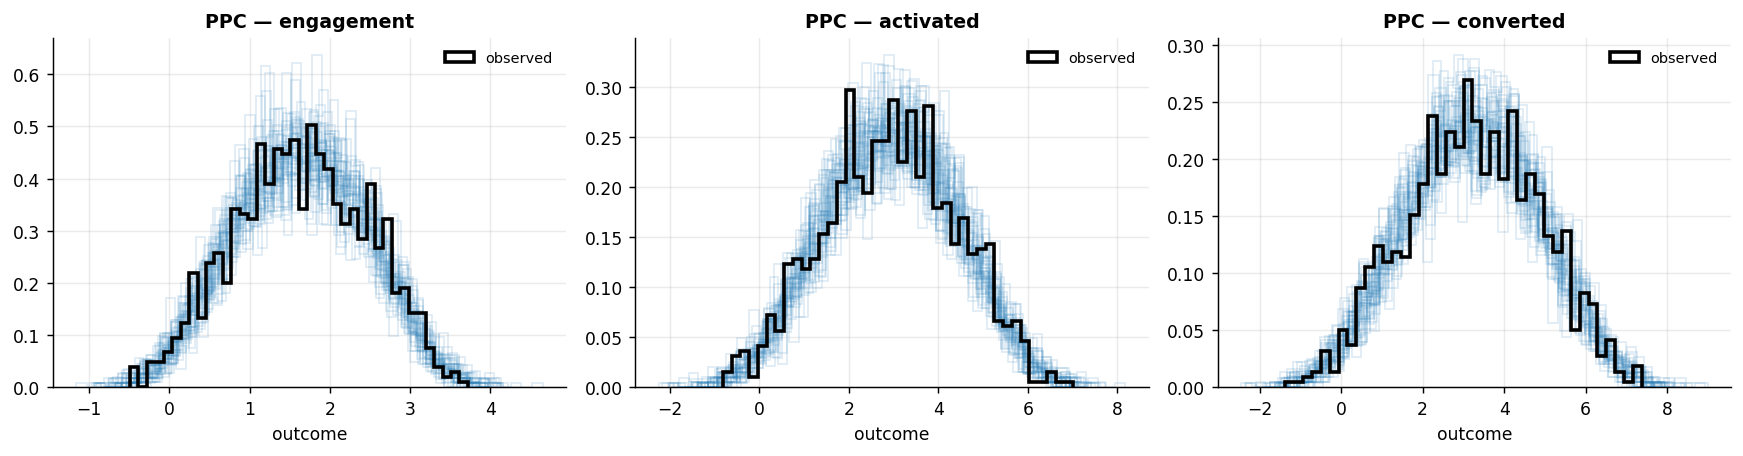

In [7]:
pp = m.predict(progressbar=False)   # posterior-predictive replicates of every endogenous stage, from the fitted chain
rng = np.random.default_rng(SEED)
fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.6))
cov_share = {}
for a, v in zip(ax, ["engagement", "activated", "converted"]):
    rep = pp.posterior_predictive[v].values.reshape(-1, len(df))
    sub = rep[rng.choice(rep.shape[0], size=min(400, rep.shape[0]), replace=False)]
    y_obs = df[v].values
    plots.ppc_plot(a, y_obs, sub[:40], title=f"PPC — {v}")
    lo, hi = np.percentile(sub, [5, 95], axis=0)        # per-user 5-95% replicate band
    cov_share[v] = float(((y_obs >= lo) & (y_obs <= hi)).mean())
fig.tight_layout()
print("Share of observed values inside the replicates' per-user 5-95% band (~90% if calibrated):  "
      + "  ·  ".join(f"{v}: {c:.0%}" for v, c in cov_share.items()))
print("No gross misfit in any stage equation -- safe to read path effects off this model."
      if all(0.82 <= c <= 0.98 for c in cov_share.values())
      else "At least one stage equation misfits -- fix the model before trusting any path product.")

**Real-data check + the naive-regression trap.** Before trusting the split: (a) do the funnel **DAG**'s (directed acyclic graph — the arrows-only causal diagram) own testable implications survive on this data — each reported below as a **partial correlation** (the correlation left between two variables after removing the conditioning set), and (b) what would a *naive* controlled regression — onboarding **plus** the mediators, all in one OLS — report for onboarding? The path queries above need neither trick; the naive regression, as the numbers show, misreads onboarding's total effect.

In [8]:
# (a) Falsify the funnel DAG against the data: does the graph survive its own implied independences?
# TWO read-outs, because they can honestly disagree. (1) The COUNT budget: at alpha=0.05 each test
# still rejects ~5% of the time even when the graph is CORRECT, so the number of violations ~
# Binomial(n_tests, 0.05) -- a lone rejection among several tests is, as a COUNT, unsurprising.
# (2) The MAGNITUDE: the count throws away how SMALL the flagged p-value is, so we also combine the
# p-values into one global test of "all implications hold" (Fisher's method; approximate -- it assumes
# the component tests are independent and exactly calibrated, and ours share one dataset).
from scipy.stats import binom, chi2, pearsonr, t as t_dist
imp = m.test_implications(alpha=0.05)
p_chance = float(binom.sf(imp.n_violations - 1, imp.n_tests, 0.05))   # P(>= this many rejections by chance)
dag_pvals = imp.results["p_value"].to_numpy(dtype=float)
dag_fisher = float(-2 * np.log(dag_pvals).sum())
dag_p_fisher = float(chi2.sf(dag_fisher, 2 * len(dag_pvals)))
print(f"Testable implications of the funnel DAG: {imp.n_tests} checked -> {imp.n_violations} violated.")
print(f"  count read-out    : P(>={imp.n_violations} rejections by chance at alpha=0.05) = {p_chance:.2f} "
      f"-> {'unsurprising' if p_chance > 0.05 else 'too many rejections'}")
print(f"  magnitude read-out: Fisher's combined test, chi2({2 * len(dag_pvals)}) = {dag_fisher:.1f}, "
      f"global p = {dag_p_fisher:.3f} -> "
      f"{'no evidence against the graph' if dag_p_fisher > 0.05 else 'REJECTS the correct graph at alpha=0.05'}")
for _, t in imp.results[imp.results.significant].iterrows():   # name the flagged test, don't leave it a mystery
    print(f"  the flagged independence: {t.x} \u22a5 {t.y} | {{{t.conditioning_set}}}  "
          f"(partial corr {t.partial_corr:+.3f}, p = {t.p_value:.3f})")

# The two read-outs disagree, and the honest resolution is not to call the flagged p "marginal" -- it
# isn't. Because we OWN this DGP we can do what real data never allows: re-run the identical battery on
# fresh worlds drawn from the graph we KNOW is right, and ask (i) how hot the global test actually runs
# and (ii) how often a global p this small shows up when nothing is wrong.
def _pcorr_p(x, y, Z=None):
    """pathmc's partial-correlation independence test, replicated in numpy (asserted identical below)."""
    if Z is None:
        return float(pearsonr(x, y)[1])
    Zi = np.column_stack([np.ones(len(x))] + list(Z))
    rx = x - Zi @ np.linalg.lstsq(Zi, x, rcond=None)[0]
    ry = y - Zi @ np.linalg.lstsq(Zi, y, rcond=None)[0]
    r_ = float(np.corrcoef(rx, ry)[0, 1]); dof = len(x) - len(Z) - 2
    return float(2 * t_dist.sf(abs(r_) * np.sqrt(dof) / np.sqrt(1 - r_**2), dof))

def _dag_pvals_of(d):
    return np.array([
        _pcorr_p(d.activated.values, d.onboarding_score.values, [d.channel_quality.values, d.engagement.values]),
        _pcorr_p(d.channel_quality.values, d.converted.values,
                 [d.activated.values, d.engagement.values, d.onboarding_score.values]),
        _pcorr_p(d.channel_quality.values, d.onboarding_score.values)])

assert np.allclose(np.sort(_dag_pvals_of(df)), np.sort(dag_pvals)), "numpy replication drifted from pathmc's tests"
N_CAL = 300 if FAST else 1000                       # pure OLS algebra, ~1 ms per world -- no load_or_run needed
dag_fisher_ps = np.empty(N_CAL)
for _s in range(N_CAL):
    _dcal, _ = dgp.funnel(n=len(df), seed=20_000 + _s)
    dag_fisher_ps[_s] = chi2.sf(-2 * np.log(_dag_pvals_of(_dcal)).sum(), 2 * len(dag_pvals))
cal_rej = float((dag_fisher_ps < 0.05).mean())
cal_p = float((dag_fisher_ps <= dag_p_fisher).mean())
print(f"Calibration under the TRUE graph ({N_CAL} fresh worlds): Fisher's global test rejects at nominal "
      f"alpha=0.05 in {cal_rej:.1%} of them (Fisher assumes independent, exactly calibrated component tests; "
      f"ours share one dataset, so some drift is expected) -- and a global p <= {dag_p_fisher:.3f} arises in "
      f"{cal_p:.1%} of correct-graph worlds.")
print("VERDICT: the count budget shrugs; the magnitude test genuinely rejects, and the calibration check "
      "says that is not an artefact of the approximation. On real data this would force a judgement call -- re-test on fresh data, "
      "interrogate the flagged pair before trusting the graph. Here we know every implied independence holds "
      f"by construction, so we log it for what it is: a knowable false positive, the ~{cal_p:.0%}-unlucky "
      "draw an honest test battery eventually serves you.")

# (b) The naive-regression trap: regress converted on onboarding AND the mediators together in one OLS.
Xn = np.column_stack([np.ones(len(df)), df['onboarding_score'].values,
                      df['engagement'].values, df['activated'].values])
beta_naive = np.linalg.lstsq(Xn, df['converted'].values, rcond=None)[0]
on_coef = beta_naive[1]
print(f"Naive OLS  converted ~ onboarding + engagement + activated : onboarding coef = {on_coef:+.3f}  "
      f"(vs TRUE total {true_effects['total']:.2f}).")
print(f"Putting the mediators in the regression collapses onboarding's coefficient toward ~0 (it now reads only the "
      f"leftover DIRECT effect, not the total). That is exactly why a naive controlled regression MISreads "
      f"onboarding's real leverage -- and why the path decomposition above, not OLS, is what you need.")

Testable implications of the funnel DAG: 3 checked -> 1 violated.
  count read-out    : P(>=1 rejections by chance at alpha=0.05) = 0.14 -> unsurprising
  magnitude read-out: Fisher's combined test, chi2(6) = 15.5, global p = 0.017 -> REJECTS the correct graph at alpha=0.05
  the flagged independence: channel_quality ⊥ onboarding_score | {}  (partial corr +0.087, p = 0.006)


Calibration under the TRUE graph (1000 fresh worlds): Fisher's global test rejects at nominal alpha=0.05 in 5.3% of them (Fisher assumes independent, exactly calibrated component tests; ours share one dataset, so some drift is expected) -- and a global p <= 0.017 arises in 2.0% of correct-graph worlds.
VERDICT: the count budget shrugs; the magnitude test genuinely rejects, and the calibration check says that is not an artefact of the approximation. On real data this would force a judgement call -- re-test on fresh data, interrogate the flagged pair before trusting the graph. Here we know every implied independence holds by construction, so we log it for what it is: a knowable false positive, the ~2%-unlucky draw an honest test battery eventually serves you.
Naive OLS  converted ~ onboarding + engagement + activated : onboarding coef = +0.059  (vs TRUE total 3.94).
Putting the mediators in the regression collapses onboarding's coefficient toward ~0 (it now reads only the leftover DIRECT

## 5 · Validate — recover the total, the paths, the DIRECT effect, and the proportion mediated

We query four things and check each against the planted truth: the **total** effect of onboarding on
conversion; the effect flowing through each **path**; the **direct** (natural direct) effect — which the
model is now free to find, and which should come out **≈ 0** if onboarding really works only through the
funnel; and the **proportion mediated** (indirect ÷ total). A proportion near 100% *with a direct effect
whose interval includes 0* is the honest version of "onboarding works almost entirely by feeding the rest
of the funnel" — a very different investment story from a direct effect.

Recovery on one dataset is necessary, not sufficient — so Step 5 closes with two harder checks:
a **replication across fresh simulations** (is the recovery calibrated, or a lucky seed?) and a
**fail → fix** refit that deliberately drops the mediators' common driver to show what unmeasured
mediator confounding actually does to the split.

In [9]:
def get_draws(res):
    d = res.draws
    return np.asarray(d() if callable(d) else d)

total_d = get_draws(m.ate("converted", "onboarding_score"))
direct_d = get_draws(m.effect("onboarding_score -> converted"))          # NDE (should be ~ 0)
via_act = get_draws(m.effect("onboarding_score -> engagement -> activated -> converted"))
via_eng = get_draws(m.effect("onboarding_score -> engagement -> converted"))
indirect_d = via_act + via_eng
prop_mediated = indirect_d / total_d

def line(lbl, d, truth):
    print(f"{lbl:38s} {d.mean():5.2f}  (true {truth:.2f})  [90% {np.quantile(d,.05):.2f}, {np.quantile(d,.95):.2f}]")
line("TOTAL onboarding -> converted", total_d, true_effects['total'])
line("  DIRECT (NDE) onboarding -> converted", direct_d, 0.0)
line("  via engagement->activated->conv", via_act, true_effects['indirect_via_engagement_activated'])
line("  via engagement->converted", via_eng, true_effects['indirect_via_engagement_only'])
pm_lo, pm_hi = np.quantile(prop_mediated, [.05, .95])
print(f"Proportion mediated (indirect / total): {prop_mediated.mean():.0%}   [90% {pm_lo:.0%}, {pm_hi:.0%}]")
print(f"The DIRECT effect's 90% interval includes 0, so the ~{prop_mediated.mean():.0%} proportion mediated is "
      f"DISCOVERED — the model was free to find a direct onboarding->conversion path and the data say there isn't one.")

TOTAL onboarding -> converted           3.92  (true 3.94)  [90% 3.76, 4.08]
  DIRECT (NDE) onboarding -> converted  0.06  (true 0.00)  [90% -0.03, 0.15]
  via engagement->activated->conv       3.14  (true 3.17)  [90% 2.96, 3.31]
  via engagement->converted             0.72  (true 0.77)  [90% 0.56, 0.89]
Proportion mediated (indirect / total): 98%   [90% 96%, 101%]
The DIRECT effect's 90% interval includes 0, so the ~98% proportion mediated is DISCOVERED — the model was free to find a direct onboarding->conversion path and the data say there isn't one.


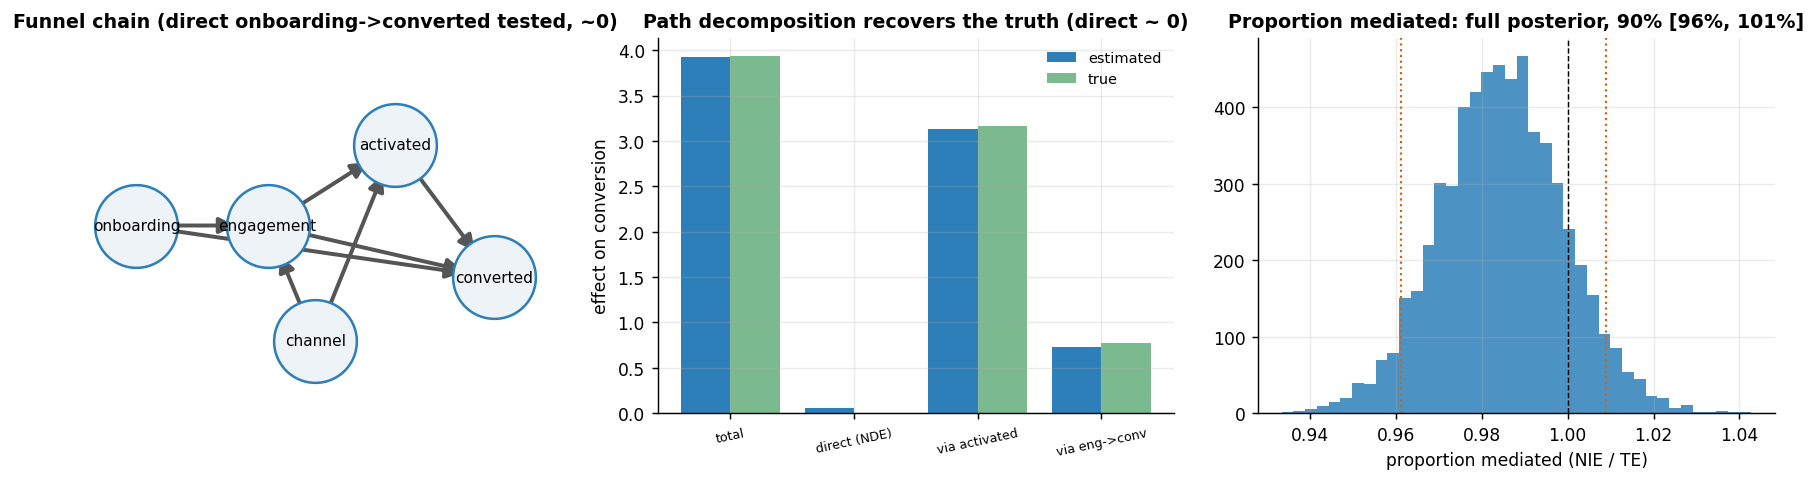

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.8))
pos = {"onboarding": (0.05,0.5), "engagement": (0.38,0.5), "activated": (0.7,0.78), "converted": (0.95,0.32), "channel": (0.5,0.1)}
edges = [("onboarding","engagement"),("engagement","activated"),("activated","converted"),
         ("engagement","converted"),("onboarding","converted"),   # onboarding->converted is TESTED (comes out ~0)
         ("channel","engagement"),("channel","activated")]
plots.draw_dag(ax[0], pos, edges, title="Funnel chain (direct onboarding->converted tested, ~0)")
labels = ["total","direct (NDE)","via activated","via eng->conv"]
means = [total_d.mean(), direct_d.mean(), via_act.mean(), via_eng.mean()]
truths_bar = [true_effects['total'], 0.0, true_effects['indirect_via_engagement_activated'], true_effects['indirect_via_engagement_only']]
x = np.arange(len(labels))
ax[1].bar(x-0.2, means, 0.4, color=plots.BLUE, label="estimated")
ax[1].bar(x+0.2, truths_bar, 0.4, color=plots.GREEN, alpha=0.6, label="true")
ax[1].set_xticks(x); ax[1].set_xticklabels(labels, fontsize=7, rotation=12); ax[1].legend(frameon=False, fontsize=8)
ax[1].set_ylabel("effect on conversion"); ax[1].set_title("Path decomposition recovers the truth (direct ~ 0)")
ax[2].hist(prop_mediated, bins=40, color=plots.BLUE, alpha=0.85)
ax[2].axvline(1.0, color="k", ls="--", lw=0.8)
for q in (pm_lo, pm_hi): ax[2].axvline(q, color=plots.ORANGE, ls=":", lw=1.2)
ax[2].set_xlabel("proportion mediated (NIE / TE)")
ax[2].set_title(f"Proportion mediated: full posterior, 90% [{pm_lo:.0%}, {pm_hi:.0%}]")
fig.tight_layout()

**How to read this.** *Left* is the causal graph we fit — including a **direct** onboarding→conversion
arrow, which we deliberately added so the model could find a direct effect if one existed. *Middle* —
the estimated total and each path effect (blue) sit on top of the planted truths (green), and the
**direct (NDE) bar is ≈ 0** (its interval includes zero): onboarding works almost entirely *through*
the funnel, and that near-100%-mediated result is now **discovered, not assumed**. *Right* — the
proportion mediated as a **full posterior** with its 90% interval, because "~100% mediated" is a
headline number people will quote and it should carry uncertainty like everything else (the dashed
line at 1.0 is "fully mediated"; draws land on either side of it because both NIE and TE are noisy).
This is the decomposition a naive "regress conversion on each stage" analysis cannot give you.

### Not a lucky seed — replication on fresh simulated worlds

Everything above is one dataset from one seed. A method that recovers the truth once might be
benefiting from friendly noise, and its intervals might be too tight (they'd then miss the truth on
other draws more than 10% of the time). So we redraw the world from the same DGP several times,
refit with deliberately short chains (posterior *means and intervals* are all we grade), and check
two things per quantity: **bias** (do the estimates center on the truth?) and **90%-interval
coverage** (do the intervals contain it about 90% of the time?). Because the four path quantities are all read off the *same* fit, they do not fail independently: an unlucky dataset tends to shift them together, so any misses cluster on a seed rather than scattering one-by-one across the table.

In [11]:
REP_SEEDS = 4 if FAST else 8
REP_FIT = dict(draws=200, tune=200, chains=2, cores=1) if FAST else dict(draws=300, tune=300, chains=2, cores=1)
truths = {"total": true_effects["total"], "direct": 0.0,
          "via_act": true_effects["indirect_via_engagement_activated"],
          "via_eng": true_effects["indirect_via_engagement_only"]}
def _replicate_seeds():
    rows_ = []
    for s in range(REP_SEEDS):
        dfs, _ = dgp.funnel(n=1000, seed=100 + s)
        ms = pathmc.model(spec, data=dfs)
        idata_s = ms.fit(random_seed=100 + s, progressbar=False, **REP_FIT)
        conv_s = est.convergence_report(idata_s)   # kept per seed so the aggregate below is checkable
        q = {"total": get_draws(ms.ate("converted", "onboarding_score")),
             "direct": get_draws(ms.effect("onboarding_score -> converted")),
             "via_act": get_draws(ms.effect("onboarding_score -> engagement -> activated -> converted")),
             "via_eng": get_draws(ms.effect("onboarding_score -> engagement -> converted"))}
        row = {"seed": 100 + s, "max_rhat": float(conv_s["max_rhat"]),
               "min_ess": float(conv_s["min_ess_bulk"]), "divergences": int(conv_s["n_divergences"])}
        for k, d in q.items():
            lo, hi = np.quantile(d, [.05, .95])
            row[k] = d.mean()
            row[k + "_ok"] = bool(lo <= truths[k] <= hi)  # did the 90% interval cover the planted truth?
        rows_.append(row)
    return rows_

rows = load_or_run("04_replicate_seeds", _replicate_seeds,
                   inputs=dict(n=REP_SEEDS, spec=spec, n_rows=1000, payload="v2-convergence", **REP_FIT))
stab = pd.DataFrame(rows)
print("planted truth:   " + "   ".join(f"{k} = {v:.2f}" for k, v in truths.items()) + "\n")
disp = stab[["seed"]].copy()
for k in truths:
    disp[k] = [f"{m:.2f} {'ok' if o else 'MISS'}" for m, o in zip(stab[k], stab[k + '_ok'])]
print(disp.to_string(index=False))
print("(cell = posterior mean + 90%-interval coverage of the planted truth)")
print(f"convergence, worst case across the {REP_SEEDS} short replication fits: "
      f"max r-hat {stab['max_rhat'].max():.3f}, min bulk-ESS {stab['min_ess'].min():,.0f}, "
      f"{int(stab['divergences'].sum())} divergences in total -- the chains are deliberately short; "
      f"means and interval coverage are all we grade here, and the worst case is printed so that claim "
      f"is checkable rather than asserted.")
ok_cols = [k + "_ok" for k in truths]
n_cov, n_int = int(stab[ok_cols].values.sum()), int(stab[ok_cols].size)
bias = {k: float(stab[k].mean() - truths[k]) for k in truths}
print(f"\n{len(truths)} quantities x {REP_SEEDS} fresh simulations -> {n_int} 90% intervals, {n_cov} covered "
      f"({n_cov / n_int:.0%}; ~90% is calibrated).  Mean bias: "
      + "  ".join(f"{k} {bias[k]:+.2f}" for k in truths) + ".")
print("Recovery is consistent across seeds -- Step 5's numbers are calibrated, not a lucky draw."
      if n_cov / n_int >= 0.75 else
      "Coverage falls short of nominal on these seeds -- treat the Step-5 intervals as optimistic.")

[cache] ADOPTING the pre-fingerprint fit for '04_replicate_seeds'. You are asserting that neither its model code nor its data has changed. Renaming, not copying, so this happens exactly once.
[cache] loaded '04_replicate_seeds' (29s fit, cached 11.2h ago) — nothing re-sampled.
planted truth:   total = 3.94   direct = 0.00   via_act = 3.17   via_eng = 0.77

 seed     total    direct   via_act   via_eng
  100   3.93 ok   0.02 ok   3.26 ok   0.65 ok
  101   4.02 ok  -0.03 ok   3.34 ok   0.71 ok
  102   3.84 ok  -0.00 ok   3.11 ok   0.73 ok
  103   3.90 ok   0.01 ok   3.22 ok   0.66 ok
  104   3.97 ok  -0.01 ok   3.19 ok   0.78 ok
  105 4.10 MISS 0.11 MISS 3.40 MISS 0.59 MISS
  106   4.03 ok  -0.04 ok   3.19 ok   0.88 ok
  107   3.94 ok  -0.05 ok   3.11 ok   0.89 ok
(cell = posterior mean + 90%-interval coverage of the planted truth)
convergence, worst case across the 8 short replication fits: max r-hat 1.020, min bulk-ESS 258, 0 divergences in total -- the chains are deliberately short; m

### Fail → fix: drop the mediators' common driver and watch the split break

Step 3 warned that with two ordered mediators, an **unmeasured confounder between the mediators**
poisons the path decomposition — and this DGP hands us the perfect prop: `channel_quality` feeds
*both* engagement and activation. So far we have always adjusted for it. Now we refit the same chain
**with every `channel_quality` term deleted**, exactly as if the growth team had never logged
acquisition channel — the single most realistic way this analysis goes wrong in production.

What should happen, mechanically: with $Q$ gone, the engagement→activated edge **absorbs $Q$'s
effect on activation** (users on good channels are both more engaged and more activated, and the
model can only route that association through `a_eng`), so `a_eng` overshoots its planted 1.6 —
and every path product built on that edge (the long path, and the graph-computed total that sums
the paths) inherits the bias. Meanwhile a plain OLS of conversion on onboarding *alone* stays
honest, because onboarding itself is exogenous here (nothing feeds into it) — which is precisely
the opening cell's claim, now with numbers: **unmeasured mediator confounding breaks the split
(and everything computed from it) even when the raw total effect of the treatment is fine.**
And the DAG falsification test from Step 4 — which on the correct graph produced only a
knowable false positive — should now catch a **true** violation. Read the printed output below
against each prediction.

In [12]:
spec_bad = '''
engagement ~ e_on*onboarding_score
activated  ~ a_eng*engagement
converted  ~ c_act*activated + c_eng*engagement + c_on*onboarding_score
'''
m_bad = pathmc.model(spec_bad, data=df)          # same data; the model just cannot SEE channel_quality
idata_bad = cached_fit(m_bad, "04_mediation_no_Q", dict(seed=SEED, fast=FAST, spec=spec_bad, **FIT),
                       random_seed=SEED, progressbar=False, cores=1, **FIT)
conv_bad = est.convergence_report(idata_bad)["summary"]
print(f"no-Q refit convergence: {conv_bad} -- the bias below is a modelling failure, not a sampling one\n")
bad = {"total": get_draws(m_bad.ate("converted", "onboarding_score")),
       "direct": get_draws(m_bad.effect("onboarding_score -> converted")),
       "via_act": get_draws(m_bad.effect("onboarding_score -> engagement -> activated -> converted")),
       "via_eng": get_draws(m_bad.effect("onboarding_score -> engagement -> converted"))}
good = {"total": total_d, "direct": direct_d, "via_act": via_act, "via_eng": via_eng}
rows = []
for k in bad:
    glo, ghi = np.quantile(good[k], [.05, .95]); blo, bhi = np.quantile(bad[k], [.05, .95])
    rows.append({"quantity": k, "truth": truths[k],
                 "with Q": good[k].mean(), "with Q covers": bool(glo <= truths[k] <= ghi),
                 "no Q": bad[k].mean(), "no Q covers": bool(blo <= truths[k] <= bhi)})
cmp_tbl = pd.DataFrame(rows)
print(cmp_tbl.round(2).to_string(index=False))
a_bad = float(m_bad.effects_summary().loc["a_eng", "mean"])
n_miss = int((~cmp_tbl["no Q covers"]).sum())
print(f"\nWith channel_quality dropped, eng->act absorbs Q's effect: a_eng = {a_bad:.2f} vs planted 1.60 -- and "
      f"{n_miss} of 4 'no Q' 90% intervals now miss the truth (vs {int((~cmp_tbl['with Q covers']).sum())} of 4 with Q).")

# The raw total from regressing converted on onboarding ALONE is still fine: onboarding is exogenous
# (no arrow points into it), so omitting Q poisons the path SPLIT, not the treatment's raw total.
Xm = np.column_stack([np.ones(len(df)), df["onboarding_score"].values])
bm, res = np.linalg.lstsq(Xm, df["converted"].values, rcond=None)[:2]
se = float(np.sqrt(res[0] / (len(df) - 2) / ((df["onboarding_score"] - df["onboarding_score"].mean())**2).sum()))
zm = abs(float(bm[1]) - truths["total"]) / se
print(f"Plain OLS converted ~ onboarding alone: {bm[1]:.2f} (SE {se:.2f}) vs true {truths['total']:.2f} -- "
      f"{'consistent with the truth' if zm < 2 else 'off from the truth'} ({zm:.1f} SE away). The split is what "
      f"breaks; the raw total was never in danger.")

# The graph's own falsification now catches the misspecification -- a TRUE positive this time.
imp_bad = m_bad.test_implications(alpha=0.05)
print(f"\ntest_implications on the no-Q graph: {imp_bad.n_tests} test(s) -> {imp_bad.n_violations} violated"
      + (":" if imp_bad.n_violations else " (nothing flagged)."))
for _, t in imp_bad.results[imp_bad.results.significant].iterrows():
    print(f"  {t.x} ⊥ {t.y} | {{{t.conditioning_set}}} FAILS (partial corr {t.partial_corr:+.3f}, p = {t.p_value:.1e}) "
          f"-- the unmeasured mediator confounder leaves a testable footprint; the Step-4 falsification "
          f"cell is not decoration, it catches exactly this misspecification.")

[cache] ADOPTING the pre-fingerprint fit for '04_mediation_no_Q'. You are asserting that neither its model code nor its data has changed. Renaming, not copying, so this happens exactly once.
[cache] loaded '04_mediation_no_Q' (15s fit, cached 11.2h ago) — nothing re-sampled.
no-Q refit convergence: max r-hat 1.000 - min ESS 4156 - divergences 0 -- the bias below is a modelling failure, not a sampling one



quantity  truth  with Q  with Q covers  no Q  no Q covers
   total   3.94    3.92           True  4.29        False
  direct   0.00    0.06           True  0.06         True
 via_act   3.17    3.14           True  3.47        False
 via_eng   0.77    0.72           True  0.76         True

With channel_quality dropped, eng->act absorbs Q's effect: a_eng = 1.71 vs planted 1.60 -- and 2 of 4 'no Q' 90% intervals now miss the truth (vs 0 of 4 with Q).
Plain OLS converted ~ onboarding alone: 4.13 (SE 0.13) vs true 3.94 -- consistent with the truth (1.5 SE away). The split is what breaks; the raw total was never in danger.

test_implications on the no-Q graph: 1 test(s) -> 1 violated:
  activated ⊥ onboarding_score | {engagement} FAILS (partial corr -0.184, p = 5.1e-09) -- the unmeasured mediator confounder leaves a testable footprint; the Step-4 falsification cell is not decoration, it catches exactly this misspecification.


### 5x · Point estimate vs posterior — what the Bayesian layer actually bought

In [13]:
# --- 5x · Step 0's classical decomposition vs the posterior, on the SAME four estimands ---------------
post = {"total": total_d, "direct": direct_d, "via_act": via_act, "via_eng": via_eng}
print("SAME estimands (§3's NDE/NIE), SAME assumptions (SI-1..SI-4), two apparatuses.")
print(f"CLASSICAL = plug-in products of OLS coefficients, {N_BOOT}-resample bootstrap CI.")
print("BAYESIAN  = posterior mean of the path products, 90% credible interval.\n")
print(f"{'':24}{'--- CLASSICAL ---':>23}{'--- BAYESIAN ---':>23}{'':>7}")
print(f"{'quantity':24}{'est':>6}{'90% CI':>17}{'mean':>6}{'90% CrI':>17}{'truth':>7}")
gaps, widths = [], []
for k in KEYS:
    r, d = cl_paths[k], post[k]
    plo, phi = np.quantile(d, [.05, .95])
    print(f"{NAMES[k]:24}{r.estimate:>6.2f}{f'[{r.ci[0]:.2f}, {r.ci[1]:.2f}]':>17}"
          f"{d.mean():>6.2f}{f'[{plo:.2f}, {phi:.2f}]':>17}{TRUTHS[k]:>7.2f}")
    gaps.append(abs(r.estimate - d.mean()))
    widths.append((phi - plo) / (r.ci[1] - r.ci[0]))
plo, phi = np.quantile(prop_mediated, [.05, .95])
print(f"{'proportion mediated':24}{cl_prop.estimate:>6.0%}"
      f"{f'[{cl_prop.ci[0]:.0%}, {cl_prop.ci[1]:.0%}]':>17}{prop_mediated.mean():>6.0%}"
      f"{f'[{plo:.0%}, {phi:.0%}]':>17}{1.0:>7.0%}")
print(f"\nLOCATION -- they agree, and not approximately: the largest gap between a")
print(f"  classical plug-in and its posterior mean is {max(gaps):.3f}, on effects of size "
      f"~{TRUTHS['total']:.1f}.")
print(f"  With n = {len(df):,} and N(0,10) priors on coefficients of order 1, the")
print("  likelihood IS the posterior, and OLS sits at its mode.")
print("WIDTH -- they agree too. posterior CrI width / bootstrap CI width:")
print("  " + ",  ".join(f"{k} {w:.2f}" for k, w in zip(KEYS, widths)) + ".")

# --- The SI-2 violation, run through BOTH arms -------------------------------------------------------
# The fail->fix above refit the BAYESIAN chain with channel_quality deleted. Do the identical thing to the
# CLASSICAL arm: drop channel_quality from the two stage regressions (use_Q=False) and re-multiply.
cl_bad = path_products(df, use_Q=False)
print("\nTHE FAIL->FIX, IN BOTH ARMS -- the SI-2 violation of §5, run through both:")
print("refit with channel_quality unobserved (the driver of BOTH mediators).")
print(f"{'quantity':26}{'truth':>7}{'classical':>11}{'Bayesian':>10}{'both off by':>14}")
for i, k in enumerate(KEYS):
    print(f"{NAMES[k]:26}{TRUTHS[k]:>7.2f}{cl_bad[i]:>11.2f}{bad[k].mean():>10.2f}"
          f"{cl_bad[i] - TRUTHS[k]:>+14.2f}")
print(f"  -> classical and Bayesian bias agree to {max(abs(cl_bad[i] - bad[k].mean()) for i, k in enumerate(KEYS)):.3f} units:")
print("     the SAME violation, the SAME wrong answer, out of both apparatuses.")
print("     A prior cannot see an unmeasured confounder; neither can a bootstrap.")

# --- What only a posterior can say: probabilities ABOUT the effects -----------------------------------
print("\nDECISION QUANTITIES — probabilities about the effects themselves:")
q = {"P(indirect > direct)": float((indirect_d > direct_d).mean()),
     "P(proportion mediated > 90%)": float((prop_mediated > 0.90).mean()),
     "P(direct effect > 0.25)": float((direct_d > 0.25).mean())}
print(f"  {'':32}{'classical':>13}{'Bayesian':>11}")
for lbl, p in q.items():
    print(f"  {lbl:32}{'not defined':>13}{p:>11.2f}")
print("  ('not defined' is not a dodge: a confidence interval attaches no")
print("   probability to a hypothesis about a fixed parameter. §6's P(ROI>1)")
print("   and its break-even cost-ratio posterior are the same species of")
print("   quantity -- and they are what finance actually asked for.)")

SAME estimands (§3's NDE/NIE), SAME assumptions (SI-1..SI-4), two apparatuses.
CLASSICAL = plug-in products of OLS coefficients, 2000-resample bootstrap CI.
BAYESIAN  = posterior mean of the path products, 90% credible interval.

                              --- CLASSICAL ---       --- BAYESIAN ---       
quantity                   est           90% CI  mean          90% CrI  truth
TOTAL onboarding->conv    3.92     [3.77, 4.07]  3.92     [3.76, 4.08]   3.94
DIRECT (NDE)              0.06    [-0.03, 0.15]  0.06    [-0.03, 0.15]   0.00
indirect eng->act->conv   3.13     [2.97, 3.31]  3.14     [2.96, 3.31]   3.17
indirect eng->conv        0.72     [0.57, 0.88]  0.72     [0.56, 0.89]   0.77
proportion mediated        98%      [96%, 101%]   98%      [96%, 101%]   100%

LOCATION -- they agree, and not approximately: the largest gap between a
  classical plug-in and its posterior mean is 0.002, on effects of size ~3.9.
  With n = 1,000 and N(0,10) priors on coefficients of order 1, the
  li

**The honest verdict — what the posterior bought, and what it did not.**

**1 · They agree, and it is not close.** Read the location line in the print-out. The classical plug-in
products and the posterior means land on top of each other — a gap of a few thousandths on effects of
size ~3.9 — and the bootstrap confidence intervals and the credible intervals agree to within a cent or two
on every bound, their widths agreeing to within the few percent printed on the WIDTH line. That is not luck and it is not disappointing: it is what *must* happen with $n=1{,}000$,
weak priors and a linear Gaussian SCM, where the posterior is the likelihood and OLS sits at its mode.
The two arms are **the same estimator wearing different clothes**. Say it plainly: on this data,
**the Bayesian machinery did not move the number, and it did not sharpen the interval.** If you came
here expecting mediation to be a place where Bayes rescues the estimate, this table is the correction.

**2 · What Bayes did *not* buy — and this is the important one.** It did not buy protection from
**SI-2**. The fail → fix block above deletes `channel_quality` — the driver of *both* mediators — and
refits; §5's table showed the Bayesian split breaking. The 5x print-out adds the sentence the notebook
owes you: **the classical arm breaks in exactly the same direction, by exactly the same amount**, to two
decimals. Of course it does. Both arms fit the same edges under the same assumption; an unmeasured
mediator–outcome confounder is not a statement about sampling variability, and *nothing in either
apparatus is looking for it*. A prior cannot see it. A bootstrap cannot see it — resampling the rows
re-estimates the same biased quantity a thousand times and reports, very precisely, how stable the bias
is. This is the whole reason §3's assumption list is not decoration and §6's sensitivity sweep is not
optional: in mediation, **the dominant uncertainty is not in the interval at all**, and both apparatuses
will hand you a tight one around a confounded number with the same untroubled face.

**3 · What the posterior *does* buy — four things, all of them real.**

- **The product carries its uncertainty exactly.** The NIE is $a\!\cdot\!b$, a product of correlated
  parameters. The classical arm needs a *device* for that — the delta method (first-order, and it fails
  when a link is weak) or a bootstrap (an approximation to the sampling distribution, and 2,000 refits).
  A joint posterior over $(a,b,c)$ needs no device: multiply the draws. The uncertainty in the product is
  simply the uncertainty in the factors, propagated — for free, and correctly, including when $\hat a$ is
  small. Step 0's own printout shows the bootstrap and the delta method agreeing *here*; the posterior is
  the arm that does not have to check.
- **Derived quantities are just functions of draws.** The **proportion mediated** is a *ratio* of two
  quantities estimated from the same fit and correlated with each other; §6's **break-even cost ratio**
  is a ratio of two lever values; §5's replication grades intervals on all four path effects at once.
  Each is one line of arithmetic on the posterior draws, with a coherent interval falling out. Classically
  each is another bespoke bootstrap, and their intervals do not have to cohere with one another.
- **The sensitivity analysis becomes a posterior, not a point.** §6's sweep does not ask "what if the
  engagement → conversion edge were 30% confounded?" once, with the fitted point estimate. It asks it
  **per draw**, so the flip point — the confounding share at which the engagement-vs-activation ranking
  reverses — comes back as a *distribution with a 90% interval*, and every quantity riding the shaved edge
  moves coherently with it: the engagement lever shrinks, and the slice it loses is *re-attributed* to
  onboarding's direct route rather than deleted, because onboarding's total is pinned by its exogeneity.
  That is the coherence a joint posterior gives you and a collection of separate bootstraps does not.
- **The decision quantities in §6 exist at all.** `P(ROI > 1)`, `P(engagement beats activated per SD)`,
  the break-even cost ratio's interval, and the `P(indirect > direct)` printed above — every one of them
  is a probability *about the effect*, and the classical column reads **not defined** for all of them.
  That is not a rhetorical concession, it is the literal state of the frequentist apparatus: it has no
  probability to attach to a hypothesis about a fixed parameter. And note the trap that makes this
  sharper than it looks: you *can* bootstrap the proportion mediated (Step 0 did), and you will get an
  interval — but the share of bootstrap replicates above 90% is **not** $P(\text{prop mediated} > 90\%)$.
  It is the frequency with which a *resampled estimate* exceeds 90%, a statement about the estimator's
  wobble, not about the world. §6's budget rule needs the latter.

> **The ledger, in one line.** Bayes bought the euro decision in §6 — the probabilities, the coherent
> ratios, the sweep with bands — and bought nothing at all on the estimate, the interval, or the
> assumption. In a chapter about mediation that last clause is the one to remember: **the hard part was
> never the arithmetic, and no amount of machinery on either side of the aisle will buy you SI-2.** Only
> a better measurement will — which is exactly why §8's recommended follow-up is an experiment that
> *randomises onboarding and logs the mediators*, not a fancier model.

## 6 · Decide, in euros — a *rankable* leverage metric, its intervals, and its fragility

Three moves, and each corrects a trap.

**(1) Rank the levers — but not by "€ per one-unit change."** A one-unit move means something completely
different per stage (one unit of `onboarding_score` is a large fraction of its whole range; one unit of
`activated` is a fraction of a standard deviation), so a €/unit ranking is not a rankable quantity — it
*reverses* when you switch to comparable **per-standard-deviation** moves. The decision-relevant metric is
**ROI = (€ value of a 1-SD lift) ÷ (€ cost to produce that 1-SD lift)** — and every € number below
carries its **90% credible interval** (table + forest plot), because a ranking whose intervals overlap
is a preference, not a decision.

**(2) Turn the stated cost into a break-even rule.** "Equal €100 per SD for every stage" is an
illustration, not a fact — real per-stage costs are what the promise of a *budget split* hinges on. So
instead of betting on one cost number, we report the **posterior break-even cost ratio** for each pair
of levers: lever A beats lever B on ROI exactly when $\text{cost}_A/\text{cost}_B <
\text{value}_A/\text{value}_B$, and the right-hand side is a posterior we already have. Hand the rule
to finance: they measure the cost ratio, the posterior says who wins — with uncertainty attached.

**(3) Stress-test the split — coherently.** The decomposition rests on *no unmeasured mediator–outcome
confounding* (SI-2). A confounder of engagement→conversion shaves the fitted edge — but the reduced form
of conversion on onboarding is a *data* quantity that no hypothesis about the confounder can move, and
onboarding is **exogenous**, so its total effect *is* that reduced form. Whatever the mediated route
loses, the **direct** route must gain: an honest sweep **re-attributes**, it does not delete. (The common
mistake is to shrink the engagement lever while freezing the direct edge, which reports onboarding's total
falling — a move exogeneity forbids.) We do that per posterior draw, so the sweep has **bands**, the "flip
point" is a posterior with an interval, and the quantity that visibly degrades turns out to be the one the
notebook leads with: the ~100%-mediated headline.

     lever  €/unit  €/SD €/SD 90% CrI  ROI (€/€)  P(ROI>1)
engagement     215   176   [172, 180]       1.76       1.0
 activated     108   159   [152, 165]       1.59       1.0
onboarding     470   133   [128, 139]       1.33       1.0

Per-UNIT vs per-SD DISAGREE: a 1-SD onboarding move is only 0.28 units (tiny) while a 1-SD activated move is 1.47 units (large), so €/unit is not rankable -- use ROI on a stated cost. At equal €100/SD the order is engagement > activated > onboarding; all three clear break-even at the stated cost.
Sampling-noise decisiveness of the eng>act gap: P(engagement > activated per SD) = 1.00 (1.00 = no overlap, ordering certain up to sampling).
Break-even rules: onboarding beats engagement on ROI once a 1-SD onboarding lift costs less than 0.76x a 1-SD engagement lift (90% [0.73, 0.79]); for activated the break-even cost ratio vs engagement is 0.90x (90% [0.86, 0.95]).


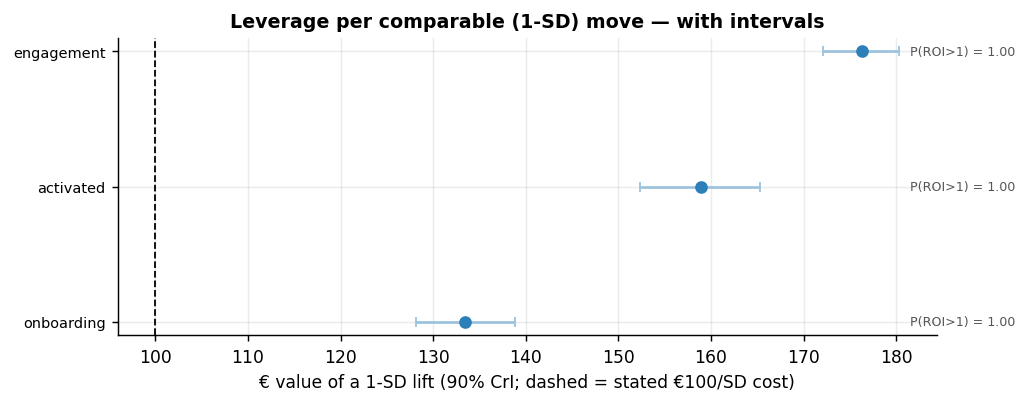

In [14]:
VALUE = 120.0
sd = {"onboarding": df.onboarding_score.std(), "engagement": df.engagement.std(), "activated": df.activated.std()}
eff = {"onboarding": total_d,
       "engagement": get_draws(m.ate("converted", "engagement")),
       "activated":  get_draws(m.ate("converted", "activated"))}
val = {k: eff[k] * sd[k] * VALUE for k in eff}            # posterior draws of the € value of a 1-SD lift
COST_SD = 100.0                                           # € to move any stage by 1 SD (STATED, illustrative)
roi = {k: val[k] / COST_SD for k in eff}
cri = {k: np.quantile(val[k], [.05, .95]) for k in eff}
tbl = pd.DataFrame({
    "lever": list(eff),
    "€/unit": [round(eff[k].mean() * VALUE) for k in eff],   # 1) unit-dependent -- NOT rankable
    "€/SD": [round(val[k].mean()) for k in eff],             # 2) comparable magnitudes
    "€/SD 90% CrI": [f"[{cri[k][0]:.0f}, {cri[k][1]:.0f}]" for k in eff],
    "ROI (€/€)": [round(roi[k].mean(), 2) for k in eff],
    "P(ROI>1)": [round((roi[k] > 1).mean(), 2) for k in eff],
}).sort_values("€/SD", ascending=False)
print(tbl.to_string(index=False))

p_eng_act = float((val["engagement"] > val["activated"]).mean())
minp = min(float((roi[k] > 1).mean()) for k in eff)
print(f"\nPer-UNIT vs per-SD DISAGREE: a 1-SD onboarding move is only {sd['onboarding']:.2f} units (tiny) while a "
      f"1-SD activated move is {sd['activated']:.2f} units (large), so €/unit is not rankable -- use ROI on a stated "
      f"cost. At equal €{COST_SD:.0f}/SD the order is {' > '.join(tbl['lever'])}; "
      + ("all three clear break-even at the stated cost." if minp > 0.9 else "not every lever clears break-even."))
print(f"Sampling-noise decisiveness of the eng>act gap: P(engagement > activated per SD) = {p_eng_act:.2f} (1.00 = no overlap, ordering certain up to sampling).")

# Break-even cost ratios: lever A beats lever B on ROI iff cost_A/cost_B < value_A/value_B (posterior).
be_onb_eng = val["onboarding"] / val["engagement"]
be_act_eng = val["activated"] / val["engagement"]
q_oe = np.quantile(be_onb_eng, [.05, .5, .95]); q_ae = np.quantile(be_act_eng, [.05, .5, .95])
print(f"Break-even rules: onboarding beats engagement on ROI once a 1-SD onboarding lift costs less than "
      f"{q_oe[1]:.2f}x a 1-SD engagement lift (90% [{q_oe[0]:.2f}, {q_oe[2]:.2f}]); for activated the break-even "
      f"cost ratio vs engagement is {q_ae[1]:.2f}x (90% [{q_ae[0]:.2f}, {q_ae[2]:.2f}]).")

fig, ax = plt.subplots(figsize=(8.0, 3.2))
order = list(tbl["lever"])
plots.forest_plot(ax, order, [float(val[k].mean()) for k in order],
                  [cri[k][0] for k in order], [cri[k][1] for k in order],
                  ref=COST_SD, xlabel="€ value of a 1-SD lift (90% CrI; dashed = stated €100/SD cost)",
                  title="Leverage per comparable (1-SD) move — with intervals",
                  annot=[f"P(ROI>1) = {(roi[k] > 1).mean():.2f}" for k in order])
fig.tight_layout()

**How to read the forest plot.** Every lever's €/SD value clears the stated €100 cost line with room
to spare, and `P(ROI>1)` saturates — which is itself informative: **sampling uncertainty is not the
binding risk here** (n=1000 and a linear SCM make these posteriors tight; the printed
P(engagement > activated) quantifies exactly how decisive the equal-cost ordering is on this data).
The intervals matter for the *break-even rules*: the posterior break-even ratios above are the
numbers to hand to finance, and their 90% intervals are what an honest budget memo quotes. What the
forest plot **cannot** show is assumption risk — the possibility that the engagement→conversion edge
itself is partly a hidden confounder's work. That is the sweep below, and it is where the ranking
actually becomes fragile.

The eng > act per-SD ordering flips once a hidden M-Y confounder explains ~52% of the fitted engagement->converted edge (90% [27%, 77%]); P(no flip within the whole edge) = 0.00.
Onboarding's TOTAL is FLAT along the sweep: €133/SD at b = 0 and €133/SD at a fully confounded edge. Onboarding is exogenous, so its total is a reduced form the sweep can only RE-ATTRIBUTE, never destroy -- SI-1 buys that, and the fail->fix already showed the same thing.
What the sweep DOES destroy is the split. At the median flip point the proportion mediated falls from 98% to 89%, the NDE rises from 0.06 to 0.44 [90% 0.35, 0.53], and P(proportion mediated > 90%) collapses from 1.00 to 0.18.
And that is the CHEAPER failure: a confounder explaining just 4% of the edge already pushes the direct effect's 90% interval off zero, against ~52% to overturn the eng-vs-act ranking. The headline -- 'onboarding pays off almost entirely through the funnel' -- is the fragile claim here, not the ranking.


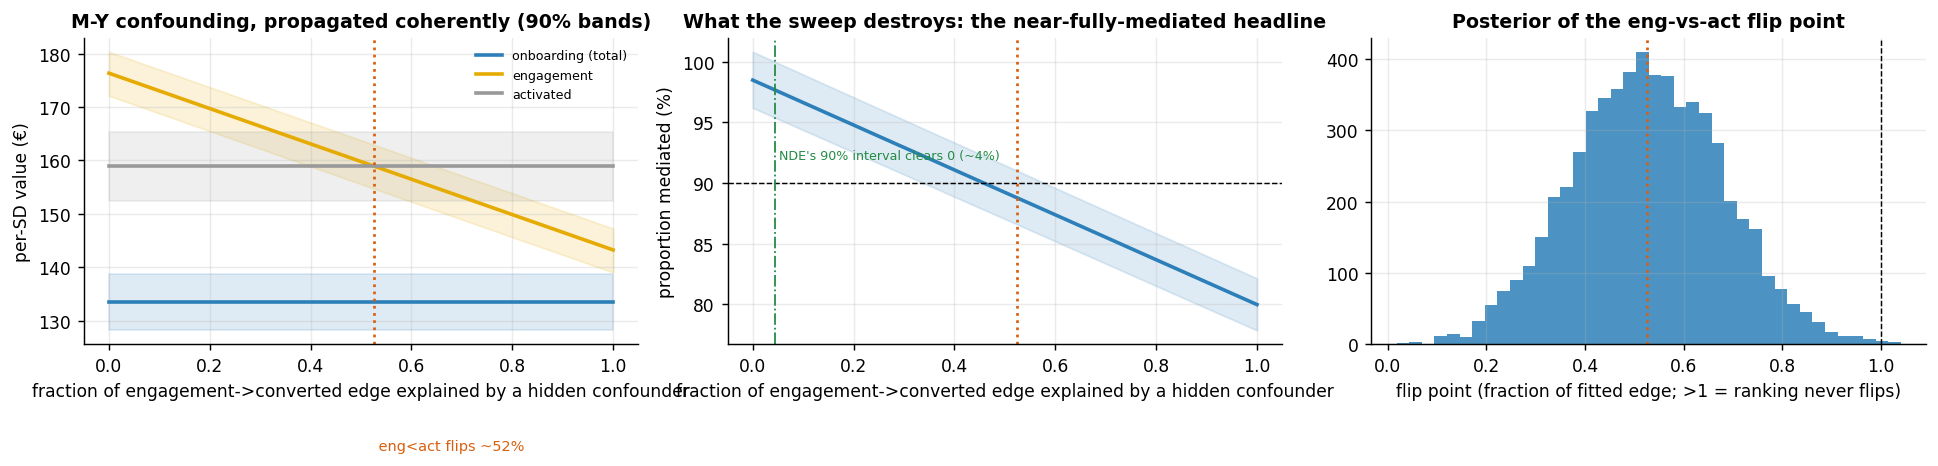

In [15]:
# Coherent M-Y sensitivity, PER POSTERIOR DRAW. A hidden confounder U of engagement->converted means
# the CAUSAL edge is (c_eng - b), not the fitted c_eng. Two things follow, and an honest sweep must
# carry BOTH -- the second is the one that is usually dropped, and it is the whole story:
#   (1) engagement's lever shrinks: its per-SD value rides (c_eng - b) + a_eng*c_act;
#   (2) the shaved slice does NOT evaporate. The reduced form of converted on O is a DATA quantity --
#       e_on*c_eng + e_on*a_eng*c_act + c_on -- and no hypothesis about U can move it. Onboarding is
#       exogenous (SI-1), so its TOTAL effect IS that reduced form. Shaving b off the mediated route
#       therefore FORCES the direct edge up by e_on*b:  c_on(b) = c_on + e_on*b. The confounded slice
#       is RE-ATTRIBUTED from the funnel to onboarding's own direct route, not deleted from the ledger.
# So onboarding's TOTAL is FLAT along the sweep (freeze c_on while shrinking c_eng and you report its
# total falling -- a move the exogeneity of O forbids). What the sweep destroys is the SPLIT: the
# 98%-mediated headline and the near-zero NDE, i.e. the two numbers this notebook leads with.
c_eng = idata.posterior["beta_converted"].sel(converted_predictors="engagement").values.ravel()
c_act = idata.posterior["beta_converted"].sel(converted_predictors="activated").values.ravel()
c_on  = idata.posterior["beta_converted"].sel(converted_predictors="onboarding_score").values.ravel()
a_eng = idata.posterior["beta_activated"].sel(activated_predictors="engagement").values.ravel()
e_on  = idata.posterior["beta_engagement"].sel(engagement_predictors="onboarding_score").values.ravel()
edge = abs(c_eng.mean()); bias_grid = np.linspace(0, edge, 21)

lever_eng = (c_eng[None, :] - bias_grid[:, None]) + (a_eng * c_act)[None, :]   # (bias, draw)
nie_b  = e_on[None, :] * lever_eng                            # NIE of onboarding, per unit
nde_b  = c_on[None, :] + e_on[None, :] * bias_grid[:, None]   # NDE, per unit -- the re-attributed edge
onb_d  = (nie_b + nde_b) * sd["onboarding"] * VALUE           # onboarding TOTAL, EUR/SD -- invariant
prop_b = nie_b / (nie_b + nde_b)                              # the headline, as it degrades
eng_d  = lever_eng * sd["engagement"] * VALUE
# Why c_act stays FROZEN along the sweep: the hypothesized U confounds engagement->converted, but given
# engagement, activated varies only through channel_quality and its own noise (eps_2) -- variation U never
# touches -- so the fitted activated->converted edge is not contaminated by U and needs no correction.
act_d = np.broadcast_to((c_act * sd["activated"] * VALUE)[None, :], eng_d.shape)
qs = lambda arr: np.quantile(arr, [.05, .5, .95], axis=1)
onb_q, eng_q, act_q, prop_q = qs(onb_d), qs(eng_d), qs(act_d), qs(prop_b)

# Per-draw flip point (closed form): eng's per-SD value equals act's at b* = c_eng + a_eng*c_act - c_act*sd_act/sd_eng.
# c_on does not appear -- the RANKING question is untouched by the re-attribution above.
b_star = c_eng + a_eng * c_act - c_act * sd["activated"] / sd["engagement"]
flip_frac = b_star / edge                                  # as a fraction of the fitted edge; >1 = never flips
f_lo, f_med, f_hi = np.quantile(flip_frac, [.05, .5, .95])
p_noflip = float((flip_frac > 1).mean())

# The SPLIT at the median flip point, and the confounding share at which the NDE stops straddling zero.
b_flip = float(f_med * edge)
nie_flip = e_on * ((c_eng - b_flip) + a_eng * c_act)
nde_flip = c_on + e_on * b_flip
prop_flip = nie_flip / (nie_flip + nde_flip)
fine = np.linspace(0, 1, 401)
nde_q05 = np.quantile(c_on[None, :] + e_on[None, :] * (fine * edge)[:, None], .05, axis=1)
nde_clears = float(fine[int(np.argmax(nde_q05 > 0))]) if bool((nde_q05 > 0).any()) else float("nan")

fig, ax = plt.subplots(1, 3, figsize=(15.0, 3.9))
xg = bias_grid / edge
for q, col, lbl in [(onb_q, plots.BLUE, "onboarding (total)"), (eng_q, plots.GOLD, "engagement"),
                    (act_q, plots.GREY, "activated")]:
    ax[0].plot(xg, q[1], color=col, lw=2, label=lbl)
    ax[0].fill_between(xg, q[0], q[2], color=col, alpha=0.15)
ax[0].axvline(f_med, color=plots.ORANGE, ls=":")
ax[0].text(f_med, float(eng_q[1].max()) * 0.6, f" eng<act flips ~{f_med:.0%}", fontsize=8, color=plots.ORANGE)
ax[0].set_xlabel("fraction of engagement->converted edge explained by a hidden confounder")
ax[0].set_ylabel("per-SD value (€)"); ax[0].set_title("M-Y confounding, propagated coherently (90% bands)")
ax[0].legend(frameon=False, fontsize=7)
ax[1].plot(xg, 100 * prop_q[1], color=plots.BLUE, lw=2)
ax[1].fill_between(xg, 100 * prop_q[0], 100 * prop_q[2], color=plots.BLUE, alpha=0.15)
ax[1].axhline(90, color="k", ls="--", lw=0.8)
ax[1].axvline(f_med, color=plots.ORANGE, ls=":")
ax[1].axvline(nde_clears, color=plots.GREEN, ls="-.", lw=1.0)
ax[1].text(nde_clears, 92, f" NDE's 90% interval clears 0 (~{nde_clears:.0%})", fontsize=7, color=plots.GREEN)
ax[1].set_xlabel("fraction of engagement->converted edge explained by a hidden confounder")
ax[1].set_ylabel("proportion mediated (%)")
ax[1].set_title("What the sweep destroys: the near-fully-mediated headline")
ax[2].hist(np.clip(flip_frac, 0, 1.5), bins=40, color=plots.BLUE, alpha=0.85)
ax[2].axvline(1.0, color="k", ls="--", lw=0.8); ax[2].axvline(f_med, color=plots.ORANGE, ls=":")
ax[2].set_xlabel("flip point (fraction of fitted edge; >1 = ranking never flips)")
ax[2].set_title("Posterior of the eng-vs-act flip point")
fig.tight_layout()
print(f"The eng > act per-SD ordering flips once a hidden M-Y confounder explains ~{f_med:.0%} of the fitted "
      f"engagement->converted edge (90% [{f_lo:.0%}, {f_hi:.0%}]); P(no flip within the whole edge) = {p_noflip:.2f}.")
print(f"Onboarding's TOTAL is FLAT along the sweep: €{onb_q[1][0]:,.0f}/SD at b = 0 and €{onb_q[1][-1]:,.0f}/SD at a "
      f"fully confounded edge. Onboarding is exogenous, so its total is a reduced form the sweep can only "
      f"RE-ATTRIBUTE, never destroy -- SI-1 buys that, and the fail->fix already showed the same thing.")
print(f"What the sweep DOES destroy is the split. At the median flip point the proportion mediated falls from "
      f"{prop_mediated.mean():.0%} to {prop_flip.mean():.0%}, the NDE rises from {direct_d.mean():.2f} to "
      f"{nde_flip.mean():.2f} [90% {np.quantile(nde_flip, .05):.2f}, {np.quantile(nde_flip, .95):.2f}], and "
      f"P(proportion mediated > 90%) collapses from {float((prop_mediated > 0.90).mean()):.2f} to "
      f"{float((prop_flip > 0.90).mean()):.2f}.")
print(f"And that is the CHEAPER failure: a confounder explaining just {nde_clears:.0%} of the edge already pushes the "
      f"direct effect's 90% interval off zero, against ~{f_med:.0%} to overturn the eng-vs-act ranking. The headline "
      f"-- 'onboarding pays off almost entirely through the funnel' -- is the fragile claim here, not the ranking.")

**How to read the sweep.** *Left* — the bands are the posterior 90% intervals *at each level of
hypothetical confounding*, so the figure separates the two kinds of uncertainty a decision-maker must
not conflate: the (narrow) sampling bands, and the (wide) horizontal question of *how much of the fitted
edge you believe*. Onboarding's total is a **flat line**, and that is not a numerical accident: onboarding
is exogenous, its total effect is a reduced form of the data, and no hypothesis about a hidden
engagement→conversion confounder can move a reduced form. The sweep can only **re-attribute** onboarding's
value between the mediated and the direct route — the same fact the fail → fix refit demonstrated when the
split broke and the raw total did not. *Middle* — so what the sweep actually destroys is the **split**: the
proportion mediated slides out of the headline, and it takes only a few percent of confounding on the same
edge for the direct effect's 90% interval to leave zero. *Right* — the flip point is itself a posterior;
quote its interval, never the median alone.

Two conclusions, and they are not the ones the forest plot led you to expect:

- **The ranking is fragile but not cheap to break.** Engagement overtakes activation only after a hidden
  confounder explains roughly *half* the fitted engagement→conversion edge (interval printed above).
- **The near-fully-mediated story is the cheap one.** Every unit of the edge the funnel loses is handed
  straight back to onboarding's direct route, so "98% mediated, direct effect straddles zero" degrades
  immediately: a few percent of confounding is enough to move the NDE's interval off zero, and about half
  the edge takes the proportion mediated down towards ~90%. If domain knowledge cannot rule out hidden
  drivers of both engagement and conversion (user intent, cohort quality), report the mediated share as an
  **upper bound**, not a finding.

### The one-paragraph decision

> **What you tell the CMO.** Onboarding's conversion value is large, and on this data essentially all of it
> is realised **downstream** (≈ 100% mediated, with its 90% interval printed in Step 5): it is a *root*
> investment whose payoff lands two stages away, so judging it by direct/last-touch conversion attribution —
> as the naive regression in Step 4 effectively does, pricing it at +0.06 against a true total of 3.94 —
> would defund it. **That total is the robust part of this analysis**: onboarding is exogenous, so its
> effect survives both stress tests in this notebook — the fail → fix refit that deletes the mediators'
> common driver, and the confounding sweep above, along which it does not move at all. Two claims are *not*
> robust, and the memo should say so. Per comparable (1-SD) move at equal cost the ranking is **engagement >
> activated > onboarding**, and that margin reverses once a hidden mediator–outcome confounder explains
> roughly half of the fitted engagement→conversion edge (interval printed above). And the *"almost entirely
> mediated"* headline is the more fragile of the two: a few percent of confounding on the same edge already
> moves the direct effect's interval off zero — so quote the mediated share with the caveat, not as a fact.
> The equal-cost assumption, by contrast, is disposable: by the break-even rule above, onboarding wins on ROI
> whenever a 1-SD onboarding lift costs less than 0.76× a 1-SD engagement lift (the whole 90% band sits below
> 0.80), so the *budget split* question reduces to a cost measurement finance can actually do. The follow-up
> is an experiment that **randomizes an onboarding improvement and logs the mediators**: randomization buys
> SI-1 by design, and measured mediators let you re-estimate the split with half the assumptions earned
> rather than assumed.

The machine-readable version, for the deck and the decision log:

In [16]:
decision = {
    "true_total": float(true_effects["total"]),
    "est_total_mean": float(total_d.mean()),
    "est_total_90": [float(np.quantile(total_d, .05)), float(np.quantile(total_d, .95))],
    "nde_mean": float(direct_d.mean()),
    "prop_mediated_mean": float(prop_mediated.mean()),
    "prop_mediated_90": [float(pm_lo), float(pm_hi)],
    "value_per_sd_eur": {k: float(val[k].mean()) for k in val},
    "ranking_per_sd_equal_cost": list(tbl["lever"]),
    "p_engagement_beats_activated_per_sd": p_eng_act,
    "flip_fraction_median": float(f_med),
    "flip_fraction_90": [float(f_lo), float(f_hi)],
    "breakeven_cost_ratio_onboarding_vs_engagement": {"median": float(q_oe[1]), "cri90": [float(q_oe[0]), float(q_oe[2])]},
    "breakeven_cost_ratio_activated_vs_engagement": {"median": float(q_ae[1]), "cri90": [float(q_ae[0]), float(q_ae[2])]},
    "replication_coverage_90": float(n_cov / n_int),
    "ppc_band_share": cov_share,
}
def _round(x, nd=3):
    if isinstance(x, float): return round(x, nd)
    if isinstance(x, dict): return {k: _round(v, nd) for k, v in x.items()}
    if isinstance(x, list): return [_round(v, nd) for v in x]
    return x
print(json.dumps(_round(decision), indent=2))

{
  "true_total": 3.938,
  "est_total_mean": 3.92,
  "est_total_90": [
    3.764,
    4.077
  ],
  "nde_mean": 0.06,
  "prop_mediated_mean": 0.985,
  "prop_mediated_90": [
    0.961,
    1.009
  ],
  "value_per_sd_eur": {
    "onboarding": 133.458,
    "engagement": 176.303,
    "activated": 158.908
  },
  "ranking_per_sd_equal_cost": [
    "engagement",
    "activated",
    "onboarding"
  ],
  "p_engagement_beats_activated_per_sd": 1.0,
  "flip_fraction_median": 0.525,
  "flip_fraction_90": [
    0.275,
    0.773
  ],
  "breakeven_cost_ratio_onboarding_vs_engagement": {
    "median": 0.757,
    "cri90": [
      0.725,
      0.788
    ]
  },
  "breakeven_cost_ratio_activated_vs_engagement": {
    "median": 0.902,
    "cri90": [
      0.857,
      0.947
    ]
  },
  "replication_coverage_90": 0.875,
  "ppc_band_share": {
    "engagement": 0.896,
    "activated": 0.893,
    "converted": 0.897
  }
}


## 7 · Caveats

- **Natural effects lean on strong assumptions** — SI-1–SI-4 from Step 3, plus (with two ordered
  mediators) no unmeasured confounding *between* the mediators. Step 5 showed with numbers what the
  latter's failure does (the fail → fix refit), and Step 6 quantified *coherently* (shrinking both
  affected levers together) how much $M\!-\!Y$ confounding would flip the leverage ranking; the point
  estimate alone hides that the engagement-vs-activation ordering is the fragile one.
- **Mediator measurement error attenuates the indirect effect.** If "engagement" is a noisy proxy for
  the behaviour that actually drives conversion (in product analytics it always is), the fitted
  mediator→outcome coefficient $b$ is biased toward zero, so the NIE is *understated* and the missing
  share silently reappears as "direct" effect. A near-zero NDE like ours is therefore doubly
  reassuring; a *large* NDE on real data should always be interrogated for mediator noise first.
- **No treatment–mediator interaction is baked in.** NDE + NIE = TE holds exactly here because the SCM
  has no $X\times M$ term. If onboarding *changes the return to* engagement (plausible: better-onboarded
  users engage more productively), the clean two-way split no longer adds up and you need the four-way
  decomposition of VanderWeele (2014) — a model-specification caveat to check before porting this
  notebook to real data.
- **A €/unit leverage ranking is not a rankable quantity** when the stage metrics live on different
  scales — it reverses under per-SD units. Decide on **ROI against a stated cost-to-move** (or better,
  the break-even cost *ratio* with its posterior interval), not €/unit.
- **Don't control away the mechanism.** The goal is to *decompose* the path; adjusting for a
  mediator when you wanted the total effect removes the very thing you're pricing (nb 05).
- **Linear-SCM decomposition is exact only if the SCM is linear** — and linearity is an *economic*
  assumption, not just a statistical one: a linear model prices the 10th SD of engagement the same as
  the 1st, i.e. **no diminishing returns**, which is exactly where a CMO will push back. Read every
  €/SD figure as a *local, first-SD* number, and for strong nonlinearities lean on `pathmc`'s
  computed effects, not hand-multiplied coefficients.

### Stress-testing SI-4 — the one pitfall we had only named

Every other assumption in this notebook earned a numeric failure demo: SI-2's mediator–mediator cousin broke in the fail → fix refit (Step 5), and hidden $M\!-\!Y$ confounding was priced by the sweep (Step 6). SI-4 — no mediator–outcome confounder that is itself *caused by the treatment* (the "recanting witness" of the mediation literature) — was only declared untestable. Untestable is not *undemonstrable*: below we plant exactly that structure (onboarding builds an early **habit** that then drives both engagement and conversion), run the same product-of-coefficients machinery, and watch the total effect stay right while the direct/indirect split goes wrong — *and stays wrong whichever way we treat the witness*, which is precisely why no adjustment strategy can rescue SI-4. This completes the pitfall set: every assumption named in Step 3 now has a demonstration of its failure mode.

In [17]:
# SI-4, violated ON PURPOSE -- the recanting witness. Onboarding creates an early `habit` that then
# drives BOTH engagement and conversion: habit sits on an indirect route (onboarding -> habit ->
# engagement -> conversion) AND on a non-mediator route (onboarding -> habit -> conversion) at once.
# Classical OLS at large n (runs in about a second), so what is on screen is structural bias, not noise.
rw_rng = np.random.default_rng(SEED + 4)
RW_N = 200_000
rw_X = rw_rng.uniform(0, 1, RW_N)                                # onboarding score, same shape as the DGP
rw_W = 1.2 * rw_X + rw_rng.normal(0, 0.4, RW_N)                  # habit: the treatment-INDUCED confounder
rw_M = 2.2 * rw_X + 0.8 * rw_W + rw_rng.normal(0, 0.4, RW_N)     # engagement (funnel slope kept at 2.2)
rw_Y = 0.9 * rw_M + 0.7 * rw_W + rw_rng.normal(0, 0.3, RW_N)     # conversion: habit also reaches it directly
RW_VIA_M = 0.9 * (2.2 + 0.8 * 1.2)     # planted: every path that ends ... -> engagement -> conversion
RW_NOT_M = 0.7 * 1.2                   # planted: onboarding -> habit -> conversion, bypassing engagement

def rw_ols(y, *cols):
    Xd = np.column_stack([np.ones(len(y))] + list(cols))
    return np.linalg.lstsq(Xd, y, rcond=None)[0]

rw_total = float(rw_ols(rw_Y, rw_X)[1])
rw_rows = []
for rw_lbl, rw_a, rw_yfit in [("habit ignored",  rw_ols(rw_M, rw_X)[1],       rw_ols(rw_Y, rw_X, rw_M)),
                              ("habit adjusted", rw_ols(rw_M, rw_X, rw_W)[1], rw_ols(rw_Y, rw_X, rw_M, rw_W))]:
    rw_rows.append((rw_lbl, float(rw_a * rw_yfit[2]), float(rw_yfit[1])))

print(f"planted: via engagement {RW_VIA_M:.2f}   bypassing engagement {RW_NOT_M:.2f}   "
      f"total {RW_VIA_M + RW_NOT_M:.2f}")
print(f"TOTAL effect from one OLS of conversion on onboarding: {rw_total:.2f} -- "
      f"SI-4 never threatens the total.\n")
print(f"{'product-formula split':26}{'NIE via eng':>12}{'bias':>8}{'direct':>9}{'NIE+direct':>12}")
for rw_lbl, rw_nie, rw_dir in rw_rows:
    print(f"  {rw_lbl:24}{rw_nie:>12.2f}{rw_nie - RW_VIA_M:>+8.2f}{rw_dir:>+9.2f}{rw_nie + rw_dir:>12.2f}")
print(f"\nIgnore the witness and the confounded engagement->conversion edge OVERSTATES the NIE by "
      f"{rw_rows[0][1] - RW_VIA_M:+.2f} while inventing a spurious negative 'direct' effect -- and the "
      f"split still adds to the total ({rw_rows[0][1] + rw_rows[0][2]:.2f}), so nothing LOOKS wrong.")
print(f"Adjust for the witness and both habit routes are blocked: the NIE UNDERSTATES by "
      f"{rw_rows[1][1] - RW_VIA_M:+.2f} and the split no longer adds up to the total "
      f"({rw_rows[1][1] + rw_rows[1][2]:.2f} vs {rw_total:.2f}) -- the witness's value vanishes from the ledger.")
print("There is no adjustment strategy in between: that is what 'the natural split is unidentified' means,\n"
      "and why SI-4 earns the label untestable rather than merely unchecked.")

planted: via engagement 2.84   bypassing engagement 0.84   total 3.68
TOTAL effect from one OLS of conversion on onboarding: 3.68 -- SI-4 never threatens the total.

product-formula split      NIE via eng    bias   direct  NIE+direct
  habit ignored                   3.91   +1.07    -0.24        3.68
  habit adjusted                  1.98   -0.86    +0.00        1.98

Ignore the witness and the confounded engagement->conversion edge OVERSTATES the NIE by +1.07 while inventing a spurious negative 'direct' effect -- and the split still adds to the total (3.68), so nothing LOOKS wrong.
Adjust for the witness and both habit routes are blocked: the NIE UNDERSTATES by -0.86 and the split no longer adds up to the total (1.98 vs 3.68) -- the witness's value vanishes from the ledger.
There is no adjustment strategy in between: that is what 'the natural split is unidentified' means,
and why SI-4 earns the label untestable rather than merely unchecked.


### When the outcome (or mediator) is 0/1

The intro invited you to port this notebook to an activation *flag* or a conversion *indicator* — and the moment the outcome equation becomes logistic, the linear-SCM convenience this chapter leans on quietly dies: **the product of coefficients is no longer the NIE**. Two separate reasons. First, *units*: a logistic $b$ lives on the log-odds scale, so $a\cdot b$ is a log-odds number, not the conversion-probability change a budget owner can price. Second, and less obvious: logistic effects are **non-collapsible** — averaging over the mediator's distribution inside a sigmoid is not the same as plugging in the mediator's mean — so even on the log-odds scale the *conditional* $a\cdot b$ overstates the *marginal* NIE, with a gap that grows with the mediator's spread. The fix is not a better product but the **mediation formula itself** (Step 3), evaluated by plug-in simulation from the fitted stage models: draw $M$ under each treatment level, push the draws through the fitted outcome model, average on the probability scale, difference. The demo below does exactly that, classically and in milliseconds; the Bayesian version runs the same recipe per posterior draw and inherits full uncertainty. (The mirror-image problem on the *treatment* side — a binary exposure that a linear first stage would misspecify — is handled in nb11 with a probit first stage.)

In [18]:
# A 0/1 conversion planted on TOP of the notebook's own funnel: keep X = onboarding, Q = channel
# quality, M = engagement exactly as simulated, and swap only the outcome equation for a logistic one
# with known latent coefficients. Two classical fits, no MCMC -- so nothing here needs load_or_run.
from scipy.special import expit, logit as logit_fn

BIN_TRUE = dict(a0=-2.5, c=0.4, b=0.9, g=0.5)   # latent: logit P(convert) = a0 + c*X + b*M + g*Q
bin_rng = np.random.default_rng(SEED + 1000)    # NOT SEED: dgp.funnel(seed=SEED) already drew those uniforms
bin_eta = (BIN_TRUE["a0"] + BIN_TRUE["c"] * df.onboarding_score
           + BIN_TRUE["b"] * df.engagement + BIN_TRUE["g"] * df.channel_quality)
df_bin = df.assign(converted_bin=(bin_rng.uniform(size=len(df)) < expit(bin_eta)).astype(int))

bin_m = smf.ols("engagement ~ onboarding_score + channel_quality", data=df_bin).fit()
bin_y = smf.logit("converted_bin ~ onboarding_score + engagement + channel_quality", data=df_bin).fit(disp=0)
bin_ab = float(bin_m.params["onboarding_score"] * bin_y.params["engagement"])   # the linear-SCM habit

def bin_nie(m_par, m_sig, y_par, rng, n_mc=400):
    """NIE of onboarding 0 -> 1 by the mediation formula, plug-in simulation: draw engagement under
    each onboarding level, push draws through the logistic outcome model, average PROBABILITIES."""
    Qv = df_bin["channel_quality"].to_numpy()
    def p_conv(x_out, x_med):
        m_draw = (m_par["Intercept"] + m_par["onboarding_score"] * x_med
                  + m_par["channel_quality"] * Qv)[None, :] + rng.normal(0, m_sig, size=(n_mc, len(Qv)))
        return float(expit(y_par["Intercept"] + y_par["onboarding_score"] * x_out
                           + y_par["engagement"] * m_draw + y_par["channel_quality"] * Qv[None, :]).mean())
    p11, p10 = p_conv(1, 1), p_conv(1, 0)
    return p11 - p10, float(logit_fn(p11) - logit_fn(p10))

bin_nie_fit_pp, bin_nie_fit_lo = bin_nie(bin_m.params, float(np.sqrt(bin_m.scale)), bin_y.params,
                                         np.random.default_rng(SEED + 2))
bin_nie_tru_pp, bin_nie_tru_lo = bin_nie(
    dict(Intercept=0.0, onboarding_score=2.2, channel_quality=1.1), 0.4,   # the planted engagement stage
    dict(Intercept=BIN_TRUE["a0"], onboarding_score=BIN_TRUE["c"],
         engagement=BIN_TRUE["b"], channel_quality=BIN_TRUE["g"]),
    np.random.default_rng(SEED + 3))

print(f"binary conversion planted on the fitted funnel (rate {df_bin.converted_bin.mean():.0%}); "
      f"fitted latent b = {bin_y.params['engagement']:.2f} (true {BIN_TRUE['b']:.2f})")
print("\nNIE of onboarding 0 -> 1, three ways:")
print(f"  naive product a*b (latent scale)        : {bin_ab:+.2f} log-odds   <- wrong units AND wrong number")
print(f"  mediation formula, plug-in from the FIT : {bin_nie_fit_pp:+.3f} probability "
      f"({bin_nie_fit_lo:+.2f} marginal log-odds)")
print(f"  mediation formula, from the TRUE model  : {bin_nie_tru_pp:+.3f} probability "
      f"({bin_nie_tru_lo:+.2f} marginal log-odds)")
print(f"\nOn the one shared scale (marginal log-odds), the product overstates the same fitted model's NIE "
      f"by {100 * (bin_ab / bin_nie_fit_lo - 1):+.0f}% -- non-collapsibility, not sampling noise: both "
      f"numbers use the SAME fitted coefficients. And the quantity finance can price is the "
      f"{100 * bin_nie_fit_pp:.0f}pp conversion lift, which no coefficient product ever equals. "
      f"Simulation from the fitted model is the porting rule for 0/1 stages.")

binary conversion planted on the fitted funnel (rate 38%); fitted latent b = 1.03 (true 0.90)

NIE of onboarding 0 -> 1, three ways:
  naive product a*b (latent scale)        : +2.22 log-odds   <- wrong units AND wrong number
  mediation formula, plug-in from the FIT : +0.451 probability (+2.08 marginal log-odds)
  mediation formula, from the TRUE model  : +0.423 probability (+1.85 marginal log-odds)

On the one shared scale (marginal log-odds), the product overstates the same fitted model's NIE by +7% -- non-collapsibility, not sampling noise: both numbers use the SAME fitted coefficients. And the quantity finance can price is the 45pp conversion lift, which no coefficient product ever equals. Simulation from the fitted model is the porting rule for 0/1 stages.


---
## Book export

The book chapter built from this notebook (`book/chapters/mediation.tex`) does not retype a single
number. Every figure it prints — every coefficient, interval, standard error, euro value, table cell
and plot — is *emitted* below by `cmp.report` into `book/build/results/nb04.json`, from which
`book/build.py` generates `macros.tex`, the booktabs tables and the vector figures the chapter
`\input`s. A number that goes stale is impossible; a number that goes *missing* is a LaTeX compile
error rather than a silent hole. The cell adds no output of its own — the notebook above is unchanged.


In [19]:
# ---------------------------------------------------------------- Book export (cmp.report)
# The book chapter (book/chapters/mediation.tex) never retypes a number: every figure it prints
# is emitted HERE, from this executed run, into book/build/results/nb04.json -> macros.tex (see
# src/cmp/report.py). A missing macro is a LaTeX compile error, never a silent hole. Figures are
# re-rendered in book style (vector PDF, no in-figure title -- the caption does that work) and
# closed immediately, so this cell changes nothing the notebook shows above.
import matplotlib as mpl
from scipy.stats import skew as _skew
from cmp import report as R

# Retire this notebook's OLD keys before writing the new ones. Without this the shard is
# read-modify-written, so a key we stop emitting keeps its macro (and its table file)
# forever — the one way a stale number could survive the injection pipeline.
R.begin("nb04")

def V(k, v, **kw):
    return R.value(f"nb04.{k}", v, **kw)

def Q(d, q):
    return float(np.quantile(np.asarray(d), q))

BOOKNAME = {"total": "Total onboarding effect",
            "direct": "Direct (NDE)",
            "via_act": "Indirect via eng. + act.",
            "via_eng": "Indirect via eng. only"}

# --- the world, and the planted truth -----------------------------------------------------
V("n_obs", int(len(df)), fmt=",d")
V("seed", int(SEED), fmt="d")
V("true_total", true_effects["total"], fmt=".3f")
V("true_via_act", true_effects["indirect_via_engagement_activated"], fmt=".3f")
V("true_via_eng", true_effects["indirect_via_engagement_only"], fmt=".2f")
V("true_nde", 0.0, fmt=".1f")
V("b_reduced", float(B_REDUCED), fmt=".2f")
V("b_direct", float(B_DIRECT), fmt=".2f")

# --- Step 0 . the classical baseline: two OLS regressions and a multiplication --------------
V("n_boot", int(N_BOOT), fmt=",d")
V("bk_a", float(a_hat), fmt=".2f")
V("bk_a_se", float(se_a), fmt=".3f")
V("bk_a_t", float(a_hat / se_a), fmt=".0f")
V("bk_b", float(b_hat), fmt=".2f")
V("bk_b_se", float(se_b), fmt=".3f")
V("bk_b_t", float(b_hat / se_b), fmt=".0f")
for _k in ("nie", "nde", "total"):
    _r = med[_k]
    V(f"bk_{_k}", _r.estimate, fmt=".2f")
    V(f"bk_{_k}_se", _r.se, fmt=".3f")
    V(f"bk_{_k}_lo", _r.ci[0], fmt=".2f")
    V(f"bk_{_k}_hi", _r.ci[1], fmt=".2f")
V("bk_prop", 100 * med["nie"].estimate / med["total"].estimate, fmt=".0f")
V("se_delta", float(se_delta), fmt=".3f")
V("se_boot", float(med["nie"].se), fmt=".3f")
V("se_ratio", float(med["nie"].se / se_delta), fmt=".2f")
V("se_gap_pct", 100 * abs(med["nie"].se / se_delta - 1), fmt=".0f")

# The chained NIE, priced classically: the SAME estimand the posterior reports (via_act + via_eng from
# cell 7's three-stage bootstrap), so the posterior sd finally has a like-for-like partner. The
# single-mediator bootstrap above prices a DIFFERENT estimand -- the reduced-form a*b, which does not
# impose the activation stage -- and the two must never be read as three prices for one number.
nie_boot_chained = boot[:, 2] + boot[:, 3]            # KEYS = [total, direct, via_act, via_eng]
V("se_boot_chained", float(nie_boot_chained.std(ddof=1)), fmt=".3f")
V("se_chain_gap_pct",
  100 * abs(indirect_d.std(ddof=1) / nie_boot_chained.std(ddof=1) - 1), fmt=".0f")

# The bootstrap replicates of a*b themselves, reproduced exactly (same seed, same resampled row
# indices as cl.mediation_product) so the chapter can SHOW the sampling distribution of the
# product rather than assert its shape. Pure-numpy OLS: identical solution, no statsmodels cost.
_T, _Qc = df["onboarding_score"].values, df["channel_quality"].values
_M, _Y = df["engagement"].values, df["converted"].values
def _ab(_ix):
    _one = np.ones(len(_ix))
    _a = np.linalg.lstsq(np.column_stack([_one, _T[_ix], _Qc[_ix]]), _M[_ix], rcond=None)[0][1]
    _b = np.linalg.lstsq(np.column_stack([_one, _T[_ix], _M[_ix], _Qc[_ix]]), _Y[_ix],
                         rcond=None)[0][2]
    return _a * _b
_rngb = np.random.default_rng(SEED)
nie_boot = np.array([_ab(_rngb.integers(0, len(df), len(df))) for _ in range(N_BOOT)])
V("nie_boot_sd", float(nie_boot.std(ddof=1)), fmt=".3f")
V("nie_boot_skew", float(_skew(nie_boot)), fmt="+.2f")
V("nie_boot_check", float(abs(nie_boot.std(ddof=1) - med["nie"].se)), fmt=".4f")

# --- the mediator-blocking trap --------------------------------------------------------------
V("blocking_b_ok", float(b_ok.params["engagement"]), fmt=".2f")
V("blocking_b_bad", float(b_bad.params["engagement"]), fmt=".2f")
V("blocking_factor", float(b_ok.params["engagement"] / b_bad.params["engagement"]), fmt=".0f")
V("blocking_nie", float(med["nie"].estimate * b_bad.params["engagement"]
                        / b_ok.params["engagement"]), fmt=".2f")

# --- the classical decomposition, chained over all three stages -------------------------------
for _k in KEYS:
    _r = cl_paths[_k]
    V(f"cl_{_k}", _r.estimate, fmt=".2f")
    V(f"cl_{_k}_lo", _r.ci[0], fmt=".2f")
    V(f"cl_{_k}_hi", _r.ci[1], fmt=".2f")
V("cl_prop", 100 * cl_prop.estimate, fmt=".0f")
V("cl_prop_lo", 100 * cl_prop.ci[0], fmt=".0f")
V("cl_prop_hi", 100 * cl_prop.ci[1], fmt=".0f")
V("n_estimands", len(KEYS), fmt="d")
V("cl_n_cover", int(sum(cl_paths[_k].ci[0] <= TRUTHS[_k] <= cl_paths[_k].ci[1] for _k in KEYS)),
  fmt="d")

# --- the Bayesian arm ---------------------------------------------------------------------------
_conv = est.convergence_report(idata)
V("n_draws", int(FIT["draws"] * FIT["chains"]), fmt=",d")
V("rhat", float(_conv["max_rhat"]), fmt=".3f")
V("ess", float(_conv["min_ess_bulk"]), fmt=",.0f")
V("divergences", int(_conv["n_divergences"]), fmt="d")
V("worst_z", float(worst), fmt=".1f")
V("prior_shift", float(shift.max()), fmt=".3f")
V("prior_shift_sd", float(rel), fmt=".2f")
_post = {"total": total_d, "direct": direct_d, "via_act": via_act, "via_eng": via_eng}
for _k, _d in _post.items():
    V(f"bayes_{_k}", float(_d.mean()), fmt=".2f")
    V(f"bayes_{_k}_lo", Q(_d, .05), fmt=".2f")
    V(f"bayes_{_k}_hi", Q(_d, .95), fmt=".2f")
V("bayes_nie", float(indirect_d.mean()), fmt=".2f")
V("bayes_nie_sd", float(indirect_d.std(ddof=1)), fmt=".3f")
V("prop_mediated", 100 * float(prop_mediated.mean()), fmt=".0f")
V("prop_lo", 100 * float(pm_lo), fmt=".0f")
V("prop_hi", 100 * float(pm_hi), fmt=".0f")

# --- diagnostics: PPC, DAG falsification, the naive controlled regression ------------------------
for _v, _c in cov_share.items():
    V(f"ppc_{_v}", 100 * float(_c), fmt=".0f")
V("imp_tests", int(imp.n_tests), fmt="d")
V("imp_violations", int(imp.n_violations), fmt="d")
V("imp_pchance", float(p_chance), fmt=".2f")
# The count read-out is only half the story, so the book gets the other half: WHICH independence was
# flagged, how small its p was, what Fisher's combined test says, and how often a correct-graph world
# produces a global p that small. The chapter is not entitled to call this rejection "marginal".
_sig = imp.results[imp.results.significant]
_flag = _sig.iloc[0] if len(_sig) else imp.results.loc[imp.results["p_value"].idxmin()]
V("imp_p_flagged", float(_flag.p_value), fmt=".3f")
V("imp_flagged_corr", float(_flag.partial_corr), fmt="+.3f")
V("imp_flagged_pair", f'{_flag.x.replace("_", " ")} $\\perp$ {_flag.y.replace("_", " ")}')
V("dag_fisher_stat", float(dag_fisher), fmt=".1f")
V("dag_fisher_df", int(2 * len(dag_pvals)), fmt="d")
V("dag_fisher_p", float(dag_p_fisher), fmt=".3f")
V("dag_cal_worlds", int(N_CAL), fmt=",d")
V("dag_cal_rej", 100 * float(cal_rej), fmt=".1f")
V("dag_cal_p", 100 * float(cal_p), fmt=".1f")
V("naive_on_coef", float(on_coef), fmt="+.2f")

# --- validation: replication across fresh worlds --------------------------------------------------
V("rep_seeds", int(REP_SEEDS), fmt="d")
V("rep_intervals", int(n_int), fmt="d")
V("rep_covered", int(n_cov), fmt="d")
V("rep_cov_pct", 100 * n_cov / n_int, fmt=".0f")
V("rep_max_bias", float(max(abs(v) for v in bias.values())), fmt=".2f")
# The replication fits are DELIBERATELY short (300 draws, 2 chains): only posterior means and interval
# coverage are graded off them, and the book must say so rather than borrow the main fit's diagnostics.
V("rep_max_rhat", float(stab["max_rhat"].max()), fmt=".3f")
V("rep_min_ess", float(stab["min_ess"].min()), fmt=",.0f")
V("rep_divergences", int(stab["divergences"].sum()), fmt="d")

# --- fail -> fix: the SI-2 violation, run through BOTH arms ----------------------------------------
V("bad_a_eng", float(a_bad), fmt=".2f")
V("bad_n_miss", int(n_miss), fmt="d")
for _i, _k in enumerate(KEYS):
    V(f"bad_bayes_{_k}", float(bad[_k].mean()), fmt=".2f")
    V(f"bad_cl_{_k}", float(cl_bad[_i]), fmt=".2f")
V("bad_arm_gap", float(max(abs(cl_bad[_i] - bad[_k].mean()) for _i, _k in enumerate(KEYS))),
  fmt=".3f")
V("bad_via_act_err_pct", 100 * abs(bad["via_act"].mean() - TRUTHS["via_act"]) / TRUTHS["via_act"],
  fmt=".0f")
V("bad_ols_total", float(bm[1]), fmt=".2f")
V("bad_ols_se", float(se), fmt=".2f")
V("bad_ols_z", float(zm), fmt=".1f")
V("bad_imp_tests", int(imp_bad.n_tests), fmt="d")
V("bad_imp_violations", int(imp_bad.n_violations), fmt="d")

# --- point estimate vs posterior --------------------------------------------------------------------
V("max_gap", float(max(gaps)), fmt=".3f")
for _k, _w in zip(KEYS, widths):
    V(f"width_{_k}", float(_w), fmt=".2f")
V("width_max", float(max(widths)), fmt=".2f")
V("width_min", float(min(widths)), fmt=".2f")
V("p_ind_gt_dir", float((indirect_d > direct_d).mean()), fmt=".2f")
V("p_prop_gt_ninety", float((prop_mediated > 0.90).mean()), fmt=".2f")
V("p_direct_gt_quarter", float((direct_d > 0.25).mean()), fmt=".2f")

# --- the decision, in euros ----------------------------------------------------------------------
V("value_per_conv", float(VALUE), fmt=".0f")
V("cost_sd", float(COST_SD), fmt=".0f")
# What last-touch attribution pays for onboarding: the naive controlled regression's coefficient,
# priced on the same per-SD scale as every other lever. This is the chapter's commercial payload in euros.
V("val_onboarding_naive", float(on_coef * sd["onboarding"] * VALUE), fmt=",.0f")
for _k in ("onboarding", "engagement", "activated"):
    V(f"sd_{_k}", float(sd[_k]), fmt=".2f")
    V(f"eur_unit_{_k}", float(eff[_k].mean() * VALUE), fmt=",.0f")
    V(f"val_{_k}", float(val[_k].mean()), fmt=",.0f")
    V(f"val_{_k}_lo", float(cri[_k][0]), fmt=",.0f")
    V(f"val_{_k}_hi", float(cri[_k][1]), fmt=",.0f")
    V(f"roi_{_k}", float(roi[_k].mean()), fmt=".2f")
    V(f"proi_{_k}", float((roi[_k] > 1).mean()), fmt=".2f")
V("ranking", " $>$ ".join(tbl["lever"]))
V("p_eng_beats_act", float(p_eng_act), fmt=".2f")
V("be_onb_eng", float(q_oe[1]), fmt=".2f")
V("be_onb_eng_lo", float(q_oe[0]), fmt=".2f")
V("be_onb_eng_hi", float(q_oe[2]), fmt=".2f")
V("be_act_eng", float(q_ae[1]), fmt=".2f")
V("be_act_eng_lo", float(q_ae[0]), fmt=".2f")
V("be_act_eng_hi", float(q_ae[2]), fmt=".2f")

# --- sensitivity: how much hidden M-Y confounding would overturn the ranking -----------------------
V("flip_med", 100 * float(f_med), fmt=".0f")
V("flip_lo", 100 * float(f_lo), fmt=".0f")
V("flip_hi", 100 * float(f_hi), fmt=".0f")
V("p_noflip", float(p_noflip), fmt=".2f")
V("edge_fitted", float(edge), fmt=".2f")          # the DIRECT engagement->converted coefficient of the
V("flip_abs", float(np.quantile(b_star, .5)), fmt=".2f")   # chain model -- not engagement's reduced form
# What the sweep destroys is the SPLIT, not onboarding's total (which is flat, by exogeneity).
V("prop_med_at_flip", 100 * float(prop_flip.mean()), fmt=".0f")
V("prop_med_at_flip_lo", 100 * Q(prop_flip, .05), fmt=".0f")
V("prop_med_at_flip_hi", 100 * Q(prop_flip, .95), fmt=".0f")
V("nde_at_flip", float(nde_flip.mean()), fmt=".2f")
V("nde_at_flip_lo", Q(nde_flip, .05), fmt=".2f")
V("nde_at_flip_hi", Q(nde_flip, .95), fmt=".2f")
V("p_prop_gt_ninety_at_flip", float((prop_flip > 0.90).mean()), fmt=".2f")
V("nde_clears_zero_pct", 100 * float(nde_clears), fmt=".0f")
V("onb_val_sweep_start", float(onb_q[1][0]), fmt=",.0f")   # the two ends of the flat blue line:
V("onb_val_sweep_end", float(onb_q[1][-1]), fmt=",.0f")    # b = 0, and a fully confounded edge

# --- SI-4, violated on purpose: the recanting witness (habit) ---------------------------------------
V("rw_n", int(RW_N), fmt=",d")
V("rw_planted_via_m", float(RW_VIA_M), fmt=".2f")
V("rw_planted_not_m", float(RW_NOT_M), fmt=".2f")
V("rw_planted_total", float(RW_VIA_M + RW_NOT_M), fmt=".2f")
V("rw_total", float(rw_total), fmt=".2f")
V("rw_nie_ignored", float(rw_rows[0][1]), fmt=".2f")
V("rw_dir_ignored", float(rw_rows[0][2]), fmt="+.2f")
V("rw_sum_ignored", float(rw_rows[0][1] + rw_rows[0][2]), fmt=".2f")
V("rw_bias_ignored", float(rw_rows[0][1] - RW_VIA_M), fmt="+.2f")
V("rw_nie_adjusted", float(rw_rows[1][1]), fmt=".2f")
V("rw_dir_adjusted", float(rw_rows[1][2]), fmt="+.2f")
V("rw_sum_adjusted", float(rw_rows[1][1] + rw_rows[1][2]), fmt=".2f")
V("rw_bias_adjusted", float(rw_rows[1][1] - RW_VIA_M), fmt="+.2f")

# --- when a funnel stage is 0/1: the product stops being the NIE -------------------------------------
V("bin_rate", 100 * float(df_bin.converted_bin.mean()), fmt=".0f")
V("bin_b_true", float(BIN_TRUE["b"]), fmt=".2f")
V("bin_b_fitted", float(bin_y.params["engagement"]), fmt=".2f")
V("bin_ab_logodds", float(bin_ab), fmt="+.2f")
V("bin_nie_pp", 100 * float(bin_nie_fit_pp), fmt=".0f")
V("bin_nie_logodds", float(bin_nie_fit_lo), fmt="+.2f")
V("bin_overstate_pct", 100 * (bin_ab / bin_nie_fit_lo - 1), fmt=".0f")

# --- tables (cell text is LaTeX-escaped by cmp.report.table, so it stays plain; captions are not) ---
R.table(pd.DataFrame([
    {"Estimand": _n, "Estimate": f"{med[_k].estimate:.2f}", "SE (bootstrap)": f"{med[_k].se:.3f}",
     "90% CI": f"[{med[_k].ci[0]:.2f}, {med[_k].ci[1]:.2f}]", "Planted": f"{_t:.2f}",
     "Covers?": "yes" if med[_k].ci[0] <= _t <= med[_k].ci[1] else "NO"}
    for _k, _n, _t in (("nie", "NIE (indirect, a*b)", true_effects["total"]),
                       ("nde", "NDE (direct, c)", 0.0),
                       ("total", "Total effect (a*b + c)", true_effects["total"]))
]), "nb04.classical", align="lrrrrc",
    caption=(f"The classical baseline: two ordinary least-squares regressions and a "
             f"multiplication, on $n = {len(df):,}$ users, with intervals from a {N_BOOT:,}-resample "
             f"nonparametric bootstrap. Every interval covers its planted value, and the direct "
             f"effect's straddles zero --- so before any likelihood, any prior or any sampler, the "
             f"answer is already: onboarding pays off almost entirely \\emph{{through}} the funnel."),
    label="tab:med:classical")

R.table(pd.DataFrame([
    {"Standard error of the indirect effect": "Delta method (first-order)",
     "Estimand": "single-mediator product", "Value": f"{se_delta:.3f}",
     "Assumes": "the product is locally linear"},
    {"Standard error of the indirect effect": f"Bootstrap ({N_BOOT:,} resamples)",
     "Estimand": "single-mediator product", "Value": f"{med['nie'].se:.3f}",
     "Assumes": "the rows are exchangeable"},
    {"Standard error of the indirect effect": f"Bootstrap ({N_BOOT:,} resamples), chained",
     "Estimand": "chained NIE (three stages)", "Value": f"{nie_boot_chained.std(ddof=1):.3f}",
     "Assumes": "the rows are exchangeable"},
    {"Standard error of the indirect effect": "Posterior sd (no device at all)",
     "Estimand": "chained NIE (three stages)", "Value": f"{indirect_d.std(ddof=1):.3f}",
     "Assumes": "the chain model's likelihood"},
]), "nb04.scales", align="llrl",
    caption=(f"Four prices --- and only two of them price the same thing. The delta method and the "
             f"bootstrap both price the single-mediator product $\\hat a\\hat b$ of "
             f"\\cref{{eq:med:product}}, and they agree to "
             f"{100 * abs(med['nie'].se / se_delta - 1):.0f}\\,\\%: the estimator is a "
             f"\\emph{{product}}, whose sampling distribution is not normal in general, but here "
             f"$\\hat a$ and $\\hat b$ are both far from zero ($t = {a_hat / se_a:.0f}$ and "
             f"$t = {b_hat / se_b:.0f}$) at $n = {len(df):,}$, the bootstrap sample skew of "
             f"$\\hat a\\hat b$ is only {_skew(nie_boot):+.2f}, and the linearisation is therefore "
             f"fine. The bootstrap was worth running, and it barely mattered. The lower two rows price "
             f"a \\emph{{different}} estimand --- the chained NIE, which imposes the activation stage "
             f"and is what the posterior of \\cref{{fig:med:product}} reports --- and they agree with "
             f"each other to "
             f"{100 * abs(indirect_d.std(ddof=1) / nie_boot_chained.std(ddof=1) - 1):.0f}\\,\\%. "
             f"Setting the posterior's {indirect_d.std(ddof=1):.3f} against the single-mediator "
             f"bootstrap's {med['nie'].se:.3f} would credit the chain model with precision that comes "
             f"from \\emph{{structure}}, not from Bayes."),
    label="tab:med:scales")

_rows = []
for _k in KEYS:
    _r, _d = cl_paths[_k], _post[_k]
    _plo, _phi = Q(_d, .05), Q(_d, .95)
    _rows.append({"Estimand": BOOKNAME[_k], "Planted": f"{TRUTHS[_k]:.2f}",
                  "Classical": f"{_r.estimate:.2f}",
                  "90% CI": f"[{_r.ci[0]:.2f}, {_r.ci[1]:.2f}]",
                  "Bayesian": f"{_d.mean():.2f}",
                  "90% CrI": f"[{_plo:.2f}, {_phi:.2f}]",
                  "Width": f"{(_phi - _plo) / (_r.ci[1] - _r.ci[0]):.2f}"})
_rows.append({"Estimand": "Proportion mediated", "Planted": "100%",
              "Classical": f"{cl_prop.estimate:.0%}",
              "90% CI": f"[{cl_prop.ci[0]:.0%}, {cl_prop.ci[1]:.0%}]",
              "Bayesian": f"{prop_mediated.mean():.0%}",
              "90% CrI": f"[{pm_lo:.0%}, {pm_hi:.0%}]",
              "Width": f"{(pm_hi - pm_lo) / (cl_prop.ci[1] - cl_prop.ci[0]):.2f}"})
R.table(pd.DataFrame(_rows), "nb04.compare", align="lrrrrrr",
        caption=(f"The same five estimands, two apparatuses. The largest gap between a classical "
                 f"plug-in and its posterior mean is {max(gaps):.3f}, on effects of size "
                 f"$\\approx {TRUTHS['total']:.1f}$; and the credible intervals are, if anything, "
                 f"the \\emph{{wider}} of the two (width ratios "
                 f"{min(widths):.2f}--{max(widths):.2f}). On this problem the Bayesian machinery "
                 f"did not move the number, and it did not sharpen the interval."),
        label="tab:med:compare")

R.table(pd.DataFrame([
    {"Estimand": BOOKNAME[_k], "Planted": f"{TRUTHS[_k]:.2f}",
     "Cl. (Q in)": f"{cl_paths[_k].estimate:.2f}",
     "Bayes (Q in)": f"{_post[_k].mean():.2f}",
     "Cl. (Q out)": f"{cl_bad[_i]:.2f}",
     "Bayes (Q out)": f"{bad[_k].mean():.2f}"}
    for _i, _k in enumerate(KEYS)
]), "nb04.failfix", align="lrrrrr",
    caption=(f"What one unobserved confounder of the two mediators does --- to \\emph{{both}} arms. "
             f"Deleting channel quality $Q$, which drives engagement \\emph{{and}} activation, "
             f"inflates the engagement-to-activation edge to {a_bad:.2f} against a planted $1.60$, "
             f"and every path product built on that edge inherits the bias: {n_miss} of "
             f"{len(KEYS)} Bayesian 90\\,\\% intervals now miss the truth. Classical and Bayesian "
             f"break in the same direction by the same amount --- they differ by at most "
             f"{max(abs(cl_bad[_i] - bad[_k].mean()) for _i, _k in enumerate(KEYS)):.3f}. A prior "
             f"cannot see an unmeasured confounder, and neither can a bootstrap."),
    label="tab:med:failfix")

R.table(pd.DataFrame([
    {"Quantity": BOOKNAME[_k], "Planted": f"{truths[_k]:.2f}",
     "Mean estimate": f"{stab[_k].mean():.2f}", "Bias": f"{bias[_k]:+.2f}",
     "Intervals covering": f"{int(stab[_k + '_ok'].sum())} of {REP_SEEDS}"}
    for _k in KEYS
]), "nb04.replication", align="lrrrc",
    caption=(f"Not a lucky seed. The whole procedure --- simulate, fit, decompose --- re-run on "
             f"{REP_SEEDS} fresh worlds drawn from the same generating model. Of the {n_int} "
             f"nominal 90\\,\\% intervals, {n_cov} cover their planted value "
             f"({100 * n_cov / n_int:.0f}\\,\\%), and the largest bias is "
             f"{max(abs(v) for v in bias.values()):.2f}. The four quantities are read off the "
             f"\\emph{{same}} fit, so misses cluster on an unlucky world rather than scattering "
             f"independently."),
    label="tab:med:replication")

R.table(pd.DataFrame([
    {"Lever (a 1-SD lift of...)": _k, "EUR per unit": f"{eff[_k].mean() * VALUE:,.0f}",
     "EUR per SD": f"{val[_k].mean():,.0f}",
     "90% CrI": f"[{cri[_k][0]:,.0f}, {cri[_k][1]:,.0f}]",
     "ROI": f"{roi[_k].mean():.2f}", "P(ROI > 1)": f"{(roi[_k] > 1).mean():.2f}"}
    for _k in list(tbl["lever"])
]), "nb04.levers", align="lrrrrr",
    caption=(f"The levers, priced. A conversion is worth \\texteuro{VALUE:.0f} and a 1-SD lift of "
             f"any stage is \\emph{{stated}} to cost \\texteuro{COST_SD:.0f}. The first two columns "
             f"disagree on the ranking, and that is the trap: euros-per-unit is not a rankable "
             f"quantity, because one unit of onboarding score (sd {sd['onboarding']:.2f}) and one "
             f"unit of activation (sd {sd['activated']:.2f}) are not comparable moves. On the "
             f"comparable per-SD scale the order is {' > '.join(tbl['lever'])}, with "
             f"$\\Prob(\\text{{engagement beats activation}}) = {p_eng_act:.2f}$ --- decisive "
             f"against \\emph{{sampling}} noise, and \\cref{{fig:med:sens}} shows it is not decisive "
             f"against \\emph{{assumption}} risk."),
    label="tab:med:levers")

R.table(pd.DataFrame([
    {"Adjustment strategy": "Habit ignored", "NIE via engagement": f"{rw_rows[0][1]:.2f}",
     "Bias": f"{rw_rows[0][1] - RW_VIA_M:+.2f}", "Direct": f"{rw_rows[0][2]:+.2f}",
     "NIE + direct": f"{rw_rows[0][1] + rw_rows[0][2]:.2f}"},
    {"Adjustment strategy": "Habit adjusted for", "NIE via engagement": f"{rw_rows[1][1]:.2f}",
     "Bias": f"{rw_rows[1][1] - RW_VIA_M:+.2f}", "Direct": f"{rw_rows[1][2]:+.2f}",
     "NIE + direct": f"{rw_rows[1][1] + rw_rows[1][2]:.2f}"},
]), "nb04.recanting", align="lrrrr",
    caption=(f"The confounder the treatment creates, and why no adjustment rescues it. Onboarding "
             f"builds an early \\emph{{habit}} which then drives both engagement and conversion --- a "
             f"recanting witness, and a violation of \\cref{{as:med:crossworld}} --- planted at "
             f"$n = {RW_N:,}$ so that what follows is structural bias, not noise. The planted split is "
             f"{RW_VIA_M:.2f} through engagement and {RW_NOT_M:.2f} around it; one regression of "
             f"conversion on onboarding still returns the total, {rw_total:.2f}. Ignore the witness and "
             f"the NIE is overstated by {rw_rows[0][1] - RW_VIA_M:+.2f} and a spurious negative direct "
             f"effect appears --- yet the two still sum to the total, so \\emph{{nothing looks wrong}}. "
             f"Adjust for it and the witness's own value leaves the ledger: the NIE is understated by "
             f"{rw_rows[1][1] - RW_VIA_M:+.2f} and the split no longer adds up "
             f"({rw_rows[1][1] + rw_rows[1][2]:.2f} against {rw_total:.2f}). There is nothing in "
             f"between. That is what \\emph{{unidentified}} means."),
    label="tab:med:recanting")

R.table(pd.DataFrame([
    {"Route to the NIE": "Naive product of coefficients", "Conversion-probability lift": "---",
     "Marginal log-odds": f"{bin_ab:+.2f}", "Scale it lives on": "latent (conditional) log-odds"},
    {"Route to the NIE": "Mediation formula, plug-in from the fitted model",
     "Conversion-probability lift": f"{bin_nie_fit_pp:+.3f}",
     "Marginal log-odds": f"{bin_nie_fit_lo:+.2f}", "Scale it lives on": "probability"},
    {"Route to the NIE": "Mediation formula, from the true model",
     "Conversion-probability lift": f"{bin_nie_tru_pp:+.3f}",
     "Marginal log-odds": f"{bin_nie_tru_lo:+.2f}", "Scale it lives on": "probability"},
]), "nb04.binary", align="lrrl",
    caption=(f"When a funnel stage is 0/1, the product of coefficients stops being the NIE --- for two "
             f"separate reasons. A logistic conversion (rate {100 * df_bin.converted_bin.mean():.0f}\\,\\%) "
             f"is planted on the same funnel, and the naive product reads "
             f"{bin_ab:+.2f} \\emph{{log-odds}}: the wrong units for a budget owner, who prices the "
             f"{100 * bin_nie_fit_pp:.0f}-percentage-point conversion lift that no coefficient product "
             f"ever equals. And even on the one shared scale --- marginal log-odds --- the product "
             f"overstates the \\emph{{same fitted model's}} NIE by "
             f"{100 * (bin_ab / bin_nie_fit_lo - 1):+.0f}\\,\\%, because logistic effects are "
             f"non-collapsible: averaging over the mediator inside a sigmoid is not the same as plugging "
             f"in its mean. Both numbers use the same coefficients, so this is not sampling noise. The "
             f"porting rule is \\cref{{eq:med:formula}} itself, evaluated by plug-in simulation from "
             f"the fitted stage models."),
    label="tab:med:binary")

# --- figures (book style: vector PDF, no in-figure title, closed so nothing renders inline) --------
with mpl.rc_context(R.book_style()):
    _f = plt.figure(figsize=(5.6, 2.9)); _a = _f.add_subplot(111)
    plots.draw_dag(_a, pos, edges)
    R.figure(_f, "nb04.dag", width=r"0.8\linewidth", caption=(
        "The funnel, as a causal graph. Onboarding is supposed to reach conversion only by pushing "
        "users into engagement and then activation; channel quality feeds \\emph{both} mediators, "
        "which is why it must be observed and adjusted for. The onboarding-to-conversion arrow is "
        "drawn and \\emph{fitted} even though the generating model has none --- so a near-zero "
        "direct effect is a discovery, not an artefact of leaving the edge out of the model."),
        label="fig:med:dag")
    plt.close(_f)

    _f = plt.figure(figsize=(6.9, 3.0)); _ax = _f.subplots(1, 2)
    _labels = ["total", "direct (NDE)", "via activation", "via engagement"]
    _x = np.arange(4)
    _mu = [float(_post[k].mean()) for k in KEYS]
    _ax[0].bar(_x - 0.2, _mu, 0.4, color=plots.BLUE, label="estimated")
    _ax[0].bar(_x + 0.2, [TRUTHS[k] for k in KEYS], 0.4, color=plots.GREEN, alpha=0.6,
               label="planted")
    _ax[0].errorbar(_x - 0.2, _mu, fmt="none", ecolor="#333333", capsize=3,
                    yerr=[[_mu[i] - Q(_post[k], .05) for i, k in enumerate(KEYS)],
                          [Q(_post[k], .95) - _mu[i] for i, k in enumerate(KEYS)]])
    _ax[0].set_xticks(_x); _ax[0].set_xticklabels(_labels, fontsize=8.5, rotation=12)
    _ax[0].axhline(0, color="k", lw=0.6)
    _ax[0].set_ylabel("effect on conversion"); _ax[0].legend(frameon=False)
    _ax[1].hist(prop_mediated, bins=40, color=plots.BLUE, alpha=0.85)
    _ax[1].axvline(1.0, color="k", ls="--", lw=0.9)
    for _q in (pm_lo, pm_hi):
        _ax[1].axvline(_q, color=plots.ORANGE, ls=":", lw=1.2)
    _ax[1].set_xlabel("proportion mediated (NIE / TE)"); _ax[1].set_ylabel("posterior draws")
    _f.tight_layout()
    R.figure(_f, "nb04.recovery", caption=(
        f"The decomposition recovers the truth. \\emph{{Left}}: posterior means with 90\\,\\% "
        f"credible intervals against the planted values; the direct effect comes back at "
        f"{direct_d.mean():.2f} and its interval straddles zero. \\emph{{Right}}: the proportion "
        f"mediated as a full posterior ({100 * prop_mediated.mean():.0f}\\,\\%, 90\\,\\% "
        f"[{100 * pm_lo:.0f}\\,\\%, {100 * pm_hi:.0f}\\,\\%]) --- a headline number people will quote, and "
        f"it should carry "
        f"uncertainty like any other. Draws land on both sides of 1.0 because the numerator and the "
        f"denominator are both estimated."), label="fig:med:recovery")
    plt.close(_f)

    _f = plt.figure(figsize=(6.9, 2.5)); _ax = _f.subplots(1, 3)
    _rngp = np.random.default_rng(SEED)
    for _a, _v in zip(_ax, ["engagement", "activated", "converted"]):
        _rep = pp.posterior_predictive[_v].values.reshape(-1, len(df))
        _sub = _rep[_rngp.choice(_rep.shape[0], size=min(400, _rep.shape[0]), replace=False)]
        plots.ppc_plot(_a, df[_v].values, _sub[:40])
        _a.set_xlabel(_v)
        _a.set_ylabel("density" if _v == "engagement" else "")
    _f.tight_layout()
    R.figure(_f, "nb04.ppc", caption=(
        f"One posterior predictive check per stage equation --- because a mediation model is three "
        f"likelihoods chained together, and a misfit in any one of them contaminates every path "
        f"product built through it. Replicated datasets (thin) against the observed distribution "
        f"(heavy). The share of observed values falling inside the per-user 90\\,\\% replicate band "
        f"is {100 * cov_share['engagement']:.0f}\\,\\%, {100 * cov_share['activated']:.0f}\\,\\% and "
        f"{100 * cov_share['converted']:.0f}\\,\\%: no gross misfit in any stage, so the path "
        f"products may be read off this model."), label="fig:med:ppc")
    plt.close(_f)

    _f = plt.figure(figsize=(6.6, 3.2)); _a = _f.add_subplot(111)
    _grid = np.linspace(float(nie_boot.min()) - 0.15, float(nie_boot.max()) + 0.15, 400)
    _a.hist(nie_boot, bins=45, density=True, color=plots.GREY, alpha=0.55,
            label=f"bootstrap of $\\hat a\\hat b$ ({N_BOOT:,} resamples)")
    _a.plot(_grid, np.exp(-0.5 * ((_grid - med["nie"].estimate) / se_delta) ** 2)
            / (se_delta * np.sqrt(2 * np.pi)), color=plots.ORANGE, lw=2,
            label="delta-method normal")
    _a.hist(nie_boot_chained, bins=45, density=True, histtype="step", color=plots.GREEN, lw=1.4,
            ls="--", label="bootstrap of the CHAINED NIE")
    _a.hist(indirect_d, bins=45, density=True, histtype="step", color=plots.BLUE, lw=1.8,
            label="posterior of the chained NIE")
    _a.set_xlabel("natural indirect effect (NIE $=a\\cdot b$)"); _a.set_ylabel("density")
    _a.legend(frameon=False)
    _f.tight_layout()
    _post_sd = float(indirect_d.std(ddof=1))
    _dir_word = "narrower" if _post_sd < float(nie_boot.std(ddof=1)) else "wider"
    R.figure(_f, "nb04.product", caption=(
        f"Pricing the uncertainty of a \\emph{{product}}. The bootstrap sampling distribution of "
        f"$\\hat a\\hat b$ (grey) has a sample skew of only {_skew(nie_boot):+.2f}, and the delta "
        f"method's normal (orange) tracks it to within "
        f"{100 * abs(med['nie'].se / se_delta - 1):.0f}\\,\\% on the standard error. The delta "
        f"method does not fail here; it fails when $\\hat a$ or $\\hat b$ sits near zero, which is "
        f"precisely the regime in which an analyst most needs an honest interval, and precisely why "
        f"one bootstraps by default. The posterior (blue) required no device at all --- multiply the "
        f"draws --- and is the {_dir_word} of the two, by "
        f"{100 * abs(_post_sd / float(nie_boot.std(ddof=1)) - 1):.0f}\\,\\%. That is not a Bayesian "
        f"free lunch: blue is the \\emph{{chained}} NIE, which uses the activation equation as extra "
        f"information about the engagement-to-conversion route, while grey and orange come from the "
        f"unrestricted reduced-form $\\hat b$. Bootstrapped on the same chained estimand (green, "
        f"dashed) the classical arm returns {nie_boot_chained.std(ddof=1):.3f} --- within "
        f"{100 * abs(_post_sd / float(nie_boot_chained.std(ddof=1)) - 1):.0f}\\,\\% of the "
        f"posterior. Structure, not paradigm."),
        label="fig:med:product")
    plt.close(_f)

    _f = plt.figure(figsize=(6.6, 2.7)); _a = _f.add_subplot(111)
    _order = list(tbl["lever"])
    plots.forest_plot(_a, _order, [float(val[k].mean()) for k in _order],
                      [cri[k][0] for k in _order], [cri[k][1] for k in _order], ref=COST_SD,
                      xlabel="€ value of a 1-SD lift (90% CrI; dashed = the stated €100/SD cost)",
                      annot=[f"P(ROI>1) = {(roi[k] > 1).mean():.2f}" for k in _order])
    _f.tight_layout()
    R.figure(_f, "nb04.forest", caption=(
        f"The levers on a comparable scale. Every stage's per-SD value clears the stated "
        f"\\texteuro{COST_SD:.0f} cost line with room to spare and $\\Prob(\\text{{ROI}} > 1)$ "
        f"saturates --- which is itself the finding: with $n = {len(df):,}$ and a linear model, "
        f"\\emph{{sampling}} uncertainty is not the binding risk in this decision. "
        f"\\Cref{{fig:med:sens}} shows what is."), label="fig:med:forest")
    plt.close(_f)

    _f = plt.figure(figsize=(6.9, 2.6)); _ax = _f.subplots(1, 3)
    _xg = bias_grid / edge
    for _q, _col, _lbl in [(onb_q, plots.BLUE, "onboarding (total)"),
                           (eng_q, plots.GOLD, "engagement"), (act_q, plots.GREY, "activated")]:
        _ax[0].plot(_xg, _q[1], color=_col, lw=2, label=_lbl)
        _ax[0].fill_between(_xg, _q[0], _q[2], color=_col, alpha=0.15)
    _ax[0].axvline(f_med, color=plots.ORANGE, ls=":")
    _ax[0].set_xlabel("share of the edge that is a hidden confounder")
    _ax[0].set_ylabel("per-SD value (€)"); _ax[0].legend(frameon=False, fontsize=7.5)
    _ax[1].plot(_xg, 100 * prop_q[1], color=plots.BLUE, lw=2)
    _ax[1].fill_between(_xg, 100 * prop_q[0], 100 * prop_q[2], color=plots.BLUE, alpha=0.15)
    _ax[1].axhline(90, color="k", ls="--", lw=0.9)
    _ax[1].axvline(f_med, color=plots.ORANGE, ls=":")
    _ax[1].axvline(nde_clears, color=plots.GREEN, ls="-.", lw=1.0)
    _ax[1].set_xlabel("share of the edge that is a hidden confounder")
    _ax[1].set_ylabel("proportion mediated (%)")
    _ax[2].hist(np.clip(flip_frac, 0, 1.5), bins=40, color=plots.BLUE, alpha=0.85)
    _ax[2].axvline(1.0, color="k", ls="--", lw=0.9)
    _ax[2].axvline(f_med, color=plots.ORANGE, ls=":")
    _ax[2].set_xlabel("flip point (share of the fitted edge; > 1 = never flips)")
    _ax[2].set_ylabel("posterior draws")
    _f.tight_layout()
    R.figure(_f, "nb04.sensitivity", caption=(
        f"The assumption, priced. A hidden engagement--conversion confounder is supposed to explain a "
        f"share of the fitted edge of \\cref{{eq:med:lik3}}, and that share is swept --- per "
        f"posterior draw, with 90\\,\\% bands, and \\emph{{coherently}}: the shaved slice is "
        f"re-attributed to onboarding's direct route rather than deleted, because onboarding is "
        f"exogenous and its total effect is a reduced form no hypothesis about the confounder can "
        f"move. \\emph{{Left}}: hence the flat blue line --- onboarding's total is "
        f"\\texteuro{onb_q[1][0]:,.0f} per SD at both ends of the sweep. What moves is the ranking: "
        f"engagement leads activation only while the confounder explains less than "
        f"{100 * f_med:.0f}\\,\\% of the edge (90\\,\\% [{100 * f_lo:.0f}\\,\\%, "
        f"{100 * f_hi:.0f}\\,\\%]; \\emph{{right}}, as a posterior), with "
        f"$\\Prob(\\text{{never flips}}) = {p_noflip:.2f}$. \\emph{{Middle}}: and what moves "
        f"faster is the headline. The proportion mediated falls to "
        f"{100 * prop_flip.mean():.0f}\\,\\% at that flip point, and a confounder explaining only "
        f"{100 * nde_clears:.0f}\\,\\% of the edge (green) is already enough for the direct "
        f"effect's 90\\,\\% interval to leave zero. Onboarding's \\emph{{total}} survives "
        f"\\cref{{as:med:si2}}; its \\emph{{mediation}} does not."),
        label="fig:med:sens")
    plt.close(_f)

print(f"book export: {len([k for k in R.load() if k.startswith('nb04.')])} keys emitted to "
      f"book/build/results/nb04.json")


book export: 215 keys emitted to book/build/results/nb04.json
